# Week 11 — Test-set showcase (11c)

**Held-out verdict on the 6 test hemispheric cycles.** This notebook reuses the
already-trained weights (no retraining) to put four butterfly diagrams side by side:

| row | source |
|-----|--------|
| Empirical | observed sunspot-emergence histograms (the reference) |
| SARGE | independent physics baseline — its own universal μ(τ) + σ(A), **fit on the training split** |
| Classical | the ButterflAI parametric model (`official_model.npz`) |
| Classical + AI base_cat | classical density + the `base_cat` reverse-diffusion residual (still on disk as `ckpt_E0metrics.ckpt`, its pre-rename stem) |

The figure is a **4 × 6 grid** — rows = the four sources, columns = the 6 test
hemicycles (12N, 13S, 15S, 19N, 22S, 24S). Every non-empirical panel is annotated with
**NLL, EMD, energy, crps_mu**; a pooled **test scorecard** closes the notebook.

Only SARGE's scalar `k` and its μ(τ) are fit here — on the **training split only**, so
nothing is tuned on the held-out test data. The classical and `base_cat` weights are loaded as-is.

> The v2 conditioning parquet (`weeks/week_10`) ships train+val only; the test rows are
> re-derived **in memory** from the v1 parquet with the same (train-fit) augmentation, so
> the committed artifacts are never modified.

In [1]:
# Standard Week 10 setup: locate the repo, install if missing.

import os, subprocess, sys

# Keep this path if working in Colab
# repo_path = "/content/butterflai"

# Use this path if working locally
repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
else:
    try:
        subprocess.run(["git", "-C", repo_path, "pull"], check=True)
    except subprocess.CalledProcessError as e:
        print(f"git pull skipped: {e}")
sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()

Already up to date.
  Installing from /d0/amunozj/git_repos/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Local
   Device   : cuda
   Seed     : 42


{'in_colab': False,
 'device': device(type='cuda'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

In [2]:
%load_ext autoreload
%autoreload 2

import os, sys, glob, json, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit, minimize_scalar
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import repeat

import pytorch_lightning as pl

In [3]:
# Bootstrap sys.path and locate artifacts. (Same resolver as 11b; see its
# comments for why week_10 is forced ahead of the week_09 stub.)
import os, sys

_week09_dir = os.path.abspath(os.path.join(repo_path, "weeks", "week_09"))
_week10_dir = os.path.abspath(os.path.join(repo_path, "weeks", "week_10"))
_week11_dir = os.path.abspath(os.path.join(repo_path, "weeks", "week_11"))
for _p in (_week09_dir, _week11_dir, _week10_dir):
    if _p in sys.path:
        sys.path.remove(_p)
    sys.path.insert(0, _p)
sys.modules.pop("conditioned_infrastructure", None)

from conditioned_infrastructure import find_week10_artifacts
paths = find_week10_artifacts(extra_required=[
    "data/composite_sunspot_groups_peak_area.csv",
])
# Repoint the module to the week_11 copy (this notebook's API home).
if _week11_dir in sys.path:
    sys.path.remove(_week11_dir)
sys.path.insert(0, _week11_dir)
sys.modules.pop("conditioned_infrastructure", None)

from unconditioned_infrastructure import make_cosine_schedule
from conditioned_infrastructure import (
    ExtendedConditionalResidualDataset,
    ExtendedConditionalDiffusionLightning,
    load_trained_experiment,
    sample_conditional_extended,
    build_model,
    block_cond_concat,
    k_run_combined,
    canonical_experiment_name,
    resolve_experiment_stems,
    discover_experiment_checkpoints,
)
from evaluation import (
    build_eval_hemicycles,
    hard_nll_combined_normalized,
    assemble_butterfly,
    butterfly_physical_checks,
    distributional_scorecard,
)
from butterflAI_model import ButterflAIModel

import conditioned_infrastructure as _ci
print(f"using conditioned_infrastructure from: {_ci.__file__}")

_WEEK10_DIR = paths["week10_dir"]
PARQUET_V2  = os.path.join(_WEEK10_DIR, "diffusion_windows_v2.parquet")
CKPT_DIR    = _WEEK10_DIR

classical   = ButterflAIModel(paths["classical_weights"])

LAT_BINS    = np.linspace(0, 45, 16)
BIN_WIDTH   = 3.0
BIN_CENTERS = 0.5 * (LAT_BINS[:-1] + LAT_BINS[1:])

T = 200
alpha_np, sigma_np, _ = make_cosine_schedule(T=T, s=0.008)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# THIS notebook is the test-set showcase: load the v1 parquet WITH the test split.
windows_v1_full = pd.read_parquet(paths["parquet_v1"])
print(f"v1 parquet (all splits): {len(windows_v1_full)} rows")
print(f"  splits: {windows_v1_full['split'].value_counts().sort_index().to_dict()}")
print(f"device : {device}")

using conditioned_infrastructure from: /d0/amunozj/git_repos/butterflai/weeks/week_11/conditioned_infrastructure.py
v1 parquet (all splits): 373 rows
  splits: {'test': 86, 'train': 232, 'val': 55}
device : cuda


---
## Step 1 — Rebuild the v2 conditioning parquet **including test**

The committed v2 parquet holds train+val only. We re-run the exact augmentation from
`11_00_build_v2.ipynb` (Tasks 60–62) on the full v1 table. Every normalization constant
(`cycle_norm` range, `opp_*` / `area_lag*` imputation means) is fit on the **train split
only** — so the train/val columns come out bit-identical to the committed parquet and the
test rows get leak-free conditioning. Nothing is written to disk.

In [4]:
# --- Task 60: cycle_norm + hemi_id (train-set cycle range) ---
windows_aug = windows_v1_full.copy()
_train_cycles = windows_aug.loc[windows_aug["split"] == "train", "cycle"]
_cmin, _cmax  = _train_cycles.min(), _train_cycles.max()
windows_aug["cycle_norm"] = 2.0 * (windows_aug["cycle"] - _cmin) / (_cmax - _cmin) - 1.0
windows_aug["hemi_id"] = np.where(windows_aug["hemisphere"] == "north", 1.0, -1.0)

# --- Task 61: contemporaneous opposite-hemisphere summaries ---
_t0 = {(int(c), str(h)): float(classical.lookup_t0(int(c), h))
       for (c, h) in classical.known_hemicycles()}

def _to_year(row):
    key = (int(row["cycle"]), str(row["hemisphere"]))
    return float(row["tau_center"]) + _t0[key] if key in _t0 else np.nan

windows_aug["_year_center"] = windows_aug.apply(_to_year, axis=1)
_flip = {"north": "south", "south": "north"}
# Opposite-hemisphere SOURCE pool = train+val only. This keeps the train/val
# opp_* columns bit-identical to the committed v2 (no test row ever informs a
# train/val feature) while still giving every test row a real opposite-
# hemisphere match (each test hemicycle's opposite hemisphere is in train/val).
_right = (windows_aug.loc[windows_aug["split"].isin(["train", "val"]),
                          ["cycle", "_year_center", "hemisphere",
                           "area_smoothed", "mu_universal", "amplitude"]]
          .assign(hemisphere=lambda d: d["hemisphere"].map(_flip))
          .rename(columns={"area_smoothed": "opp_area_smoothed",
                           "mu_universal":  "opp_mu_universal",
                           "amplitude":     "opp_amplitude"}))
_TOL = 0.4
_left = (windows_aug.reset_index().rename(columns={"index": "_rowid"})
         .sort_values("_year_center"))
_right = _right.sort_values("_year_center")
_merged = pd.merge_asof(_left, _right, on="_year_center", by=["cycle", "hemisphere"],
                        direction="nearest", tolerance=_TOL)
windows_aug = (_merged.sort_values("_rowid")
               .drop(columns=["_rowid", "_year_center"]).reset_index(drop=True))
windows_aug["opp_valid"] = windows_aug["opp_area_smoothed"].notna().astype(np.float32)
_opp_cols = ["opp_area_smoothed", "opp_mu_universal", "opp_amplitude"]
_train_mask = (windows_aug["split"] == "train") & (windows_aug["opp_valid"] == 1.0)
for _c in _opp_cols:
    windows_aug[_c] = windows_aug[_c].fillna(windows_aug.loc[_train_mask, _c].mean())

# --- Task 62: smoothed-area trajectory (K lagged values) ---
K_LAGS = 4
_sorted = windows_aug.sort_values(["cycle", "hemisphere", "tau_center"])
_lag_cols = [f"area_lag{k}" for k in range(1, K_LAGS + 1)]
for k, col in enumerate(_lag_cols, start=1):
    _sorted[col] = _sorted.groupby(["cycle", "hemisphere"])["area_smoothed"].shift(k)
_sorted["traj_valid"] = (~_sorted[_lag_cols].isna().any(axis=1)).astype(np.float32)
_train_mask = (_sorted["split"] == "train") & (_sorted["traj_valid"] == 1.0)
for col in _lag_cols:
    _sorted[col] = _sorted[col].fillna(_sorted.loc[_train_mask, col].mean())
windows_v2_full = _sorted.sort_index()

# Sanity: the train/val rows must match the committed v2 parquet bit-for-bit.
_committed = pd.read_parquet(PARQUET_V2)
_tv = windows_v2_full[windows_v2_full["split"].isin(["train", "val"])].reset_index(drop=True)
assert len(_tv) == len(_committed), (len(_tv), len(_committed))
_NEW = ["cycle_norm", "hemi_id", *_opp_cols, *_lag_cols]
for c in _NEW:
    a = _tv.sort_values(["cycle", "hemisphere", "tau_center"])[c].to_numpy()
    b = _committed.sort_values(["cycle", "hemisphere", "tau_center"])[c].to_numpy()
    assert np.allclose(a, b, equal_nan=True), f"drift vs committed v2 in {c}"
print("v2(full) rows:", len(windows_v2_full),
      "| splits:", windows_v2_full["split"].value_counts().sort_index().to_dict())
print("train/val columns reproduce the committed v2 parquet exactly.")

v2(full) rows: 373 | splits: {'test': 86, 'train': 232, 'val': 55}
train/val columns reproduce the committed v2 parquet exactly.


---
## Step 2 — Build the 6 test hemicycles and load the `base_cat` diffusion model

`build_eval_hemicycles` re-windows the raw catalog 6-monthly and tags each window with its
v2 conditioning superset. We ask for `splits=("test",)` so only the held-out hemicycles are
built. `base_cat` is the baseline experiment (base conditioning, `concat` arch, no CFG, no Fourier
lifting) → sampled unguided at `w=0`. Set `SHOWCASE_NAME` to showcase a different variant.

In [5]:
hemicycles, GROUP_COLS = build_eval_hemicycles(
    raw_csv_path=paths["raw_csv"],
    windows_v2=windows_v2_full,
    classical=classical,
    splits=("test",),
)
test_hcs = sorted([hc for hc in hemicycles if hc["split"] == "test"],
                  key=lambda h: (h["cycle"], h["hemisphere"]))

def tag_of(hc):
    return f"{hc['cycle']:02d}{hc['hemisphere'][0].upper()}"

tags = [tag_of(hc) for hc in test_hcs]
print(f"test hemicycles ({len(test_hcs)}): {tags}")
print(f"windows per hemicycle: {[len(hc['blocks']) for hc in test_hcs]}")
assert len(test_hcs) == 6, "expected exactly 6 test hemicycles"
assert set(tags) == {"12N", "13S", "15S", "19N", "22S", "24S"}, tags

test hemicycles (6): ['12N', '13S', '15S', '19N', '22S', '24S']
windows per hemicycle: [11, 15, 13, 18, 16, 13]


In [6]:
# The showcased variant. Names are canonical (see 11a's Task 65): the
# baseline is base_cat — base conditioning, concat arch, no CFG, no Fourier.
# Its weights predate the rename and still live in ckpt_E0metrics.ckpt, which
# resolve_experiment_stems() finds for us; nothing on disk was renamed.
_BASE_TEMPLATE = {
    "arch":           "concat",
    "consumed_keys":  ["cond_base"],
    "groups":         ["base"],
    "hidden_dim":     128,
    "n_layers":       3,
    "fourier":        False,
    "cond_dropout_p": 0.0,
    "max_epochs":     20000,
    "lr":             1e-3,
    "batch_size":     64,
}
def _spec(**overrides):
    d = dict(_BASE_TEMPLATE); d.update(overrides); return d

SHOWCASE_NAME = "base_cat"
SHOWCASE_CFG  = _spec()
assert canonical_experiment_name(SHOWCASE_CFG, _BASE_TEMPLATE) == SHOWCASE_NAME, \
    "SHOWCASE_CFG does not describe SHOWCASE_NAME — fix one or the other"

_known, _ = resolve_experiment_stems(
    discover_experiment_checkpoints(CKPT_DIR), {SHOWCASE_NAME: SHOWCASE_CFG})
assert _known, (f"no checkpoint for {SHOWCASE_NAME} in {CKPT_DIR} "
                f"(looked for ckpt_{SHOWCASE_NAME}.ckpt and its pre-rename stem)")
SHOWCASE_STEM = dict(_known)[SHOWCASE_NAME]

# Row labels for every figure and table below, derived from the run name so
# relabeling the showcase is a one-line change.
AI_ROW   = f"Classical + AI {SHOWCASE_NAME}"
AI_SHORT = f"Classical+AI {SHOWCASE_NAME}"

# load_trained_experiment builds its train/val datasets from windows_v2_full and
# loads the pre-trained checkpoint. Standardization comes from the checkpoint buffers.
ai_lit, ai_train_ds, ai_val_ds, ai_total_dim = load_trained_experiment(
    SHOWCASE_STEM, SHOWCASE_CFG, windows_v2_full, CKPT_DIR, alpha_np, sigma_np,
)
ai_lit.eval()
print(f"loaded {SHOWCASE_NAME} (ckpt_{SHOWCASE_STEM}.ckpt): "
      f"cond_dim={ai_total_dim}, guidance w=0 (no CFG)")


loaded E0metrics: cond_dim=4, guidance w=0 (no CFG)


---
## Step 3 — Fit SARGE on the training split

SARGE is a fully independent physics baseline. Following `week_06/fit_sarge_sigma_width.py`
we fit **only two things on the training hemicycles**: the universal mean path
μ(τ)=a·exp(−τ/b) and the single spread scale `k` in
σ_λ(A) = 1.5° + 3.8°·[1 − exp(−A/k)]. The 15°-crossing t0 is computed for **all**
hemicycles (data-driven, so we can place the test bands), and the global smoothed
total-area series drives σ per window. Nothing about SARGE is tuned on val or test.

In [7]:
# --- SARGE constants (paper-prescribed; only k is fit) ---
SARGE_SIGMA_MIN, SARGE_SIGMA_AMP = 1.5, 3.8
AREA_THRESHOLD, MIN_CYCLE = 30, 12
N_BINS, MIN_LATS_BIN, MIN_LATS_YEAR, SMOOTH_WIN = 20, 10, 5, 365

# train hemicycle set from the diffusion split -> SARGE never sees val/test.
_hc_split = (windows_v2_full.groupby(["cycle", "hemisphere"])["split"]
             .agg(lambda s: s.iloc[0]).to_dict())
train_hc = {(int(c), str(h)) for (c, h), s in _hc_split.items() if s == "train"}
print(f"SARGE fit on {len(train_hc)} train hemicycles")

# raw catalog
sdf = pd.read_csv(paths["raw_csv"], parse_dates=[[0, 1, 2]], keep_date_col=False)
sdf.rename(columns={"year_month_day": "date"}, inplace=True)
sdf = sdf[sdf["latitude"].notna()].copy()
sdf["hemisphere"]   = np.where(sdf["latitude"] >= 0, "north", "south")
sdf["abs_latitude"] = sdf["latitude"].abs()
sdf["year"]         = sdf["date"].dt.year
sdf["decimal_year"] = sdf["date"].dt.year + sdf["date"].dt.dayofyear / 365.25
sdf = sdf[sdf["correctedArea"] > AREA_THRESHOLD].copy()
sdf = sdf.dropna(subset=["CYCLE"]).copy()
sdf["CYCLE"] = sdf["CYCLE"].astype(int)

def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

# 15-degree crossing t0 for ALL hemicycles (test included -> placeable bands)
def _t0_15(group):
    ym = group.groupby("year")["abs_latitude"].mean().sort_index()
    years, means = ym.index.values, ym.values
    below = means < 15.0
    if not below.any() or below.all():
        return None
    i1 = int(np.argmax(below))
    if i1 == 0:
        return None
    y0, m0 = years[i1 - 1], means[i1 - 1]
    y1, m1 = years[i1], means[i1]
    return float(y0 + (15.0 - m0) / (m1 - m0))

t0_lookup = {}
for (cyc, hemi), g in sdf.groupby(["CYCLE", "hemisphere"]):
    v = _t0_15(g)
    if v is not None:
        t0_lookup[(int(cyc), hemi)] = v
sdf["t0"]  = sdf.apply(lambda r: t0_lookup.get((int(r["CYCLE"]), r["hemisphere"]), np.nan), axis=1)
sdf["tau"] = sdf["decimal_year"] - sdf["t0"]

# universal mu(tau): fit on TRAIN hemicycle bins only; refine t0 for all.
cycles = [c for c in sorted(sdf["CYCLE"].dropna().unique()) if c >= MIN_CYCLE]
all_t, all_m, hemibins = [], [], {}
for cyc in cycles:
    for hemi in ["north", "south"]:
        key = (int(cyc), hemi)
        if key not in t0_lookup:
            continue
        ds = sdf[(sdf["CYCLE"] == cyc) & (sdf["hemisphere"] == hemi) & sdf["tau"].notna()]
        if len(ds) < 50:
            continue
        bins = np.linspace(ds["tau"].min(), ds["tau"].max(), N_BINS + 1)
        bc = 0.5 * (bins[:-1] + bins[1:])
        bt, bm = [], []
        for i in range(N_BINS):
            lb = ds.loc[(ds["tau"] >= bins[i]) & (ds["tau"] < bins[i + 1]), "abs_latitude"].values
            if len(lb) < MIN_LATS_BIN:
                continue
            mu_f, _ = sp_norm.fit(lb)
            bt.append(bc[i]); bm.append(mu_f)
        if len(bt) < 5:
            continue
        bt, bm = np.array(bt), np.array(bm)
        hemibins[key] = (bt, bm)
        if key in train_hc:                      # TRAIN-only universal fit
            all_t.extend(bt); all_m.extend(bm)

(a_mu_univ, b_mu_univ), _ = curve_fit(exp_decay, all_t, all_m, p0=[15.0, 5.0])
print(f"universal mu(tau): a={a_mu_univ:.3f} deg, b={b_mu_univ:.3f} yr  (train-only)")

t0_refined = {}
for key, (bt, bm) in hemibins.items():
    def _res(dt, _bt=bt, _bm=bm):
        return np.sum((_bm - exp_decay(_bt - dt, a_mu_univ, b_mu_univ)) ** 2)
    t0_refined[key] = t0_lookup[key] + minimize_scalar(_res, bounds=(-4, 4),
                                                       method="bounded").x

# global smoothed total area (both hemispheres; physical series, not split-specific)
_dn = sdf[sdf["hemisphere"] == "north"].groupby("date")["correctedArea"].sum()
_dsouth = sdf[sdf["hemisphere"] == "south"].groupby("date")["correctedArea"].sum()
_dr = pd.date_range(min(_dn.index.min(), _dsouth.index.min()),
                    max(_dn.index.max(), _dsouth.index.max()), freq="D")
_dn = _dn.reindex(_dr, fill_value=0); _dsouth = _dsouth.reindex(_dr, fill_value=0)
smooth_total = (_dn + _dsouth).rolling(SMOOTH_WIN, center=True,
                                       min_periods=SMOOTH_WIN // 3).mean()

def A_total_at(decimal_year):
    """Global smoothed total area (MSH) nearest to a decimal year, or nan."""
    yr = int(np.floor(decimal_year))
    d  = pd.Timestamp(year=yr, month=1, day=1) + pd.Timedelta(days=(decimal_year - yr) * 365.25)
    idx = smooth_total.index.get_indexer([d], method="nearest")[0]
    v = float(smooth_total.iloc[idx])
    return v if np.isfinite(v) and v > 0 else np.nan

# k fit: TRAIN hemicycles only (min mean per-year NLL)
def sarge_sigma(A, k):
    return SARGE_SIGMA_MIN + SARGE_SIGMA_AMP * (1.0 - np.exp(-A / k))

_cache = []   # (lats, mu, A_total) per train (cycle, hemisphere, year)
for cyc in cycles:
    for hemi in ["north", "south"]:
        key = (int(cyc), hemi)
        if key not in t0_refined or key not in train_hc:
            continue
        dch = sdf[(sdf["CYCLE"] == cyc) & (sdf["hemisphere"] == hemi) & sdf["tau"].notna()]
        for yr in sorted(dch["year"].unique()):
            lats = dch.loc[dch["year"] == yr, "abs_latitude"].values
            if len(lats) < MIN_LATS_YEAR:
                continue
            mu = float(exp_decay((yr + 0.5) - t0_refined[key], a_mu_univ, b_mu_univ))
            A  = A_total_at(yr + 0.5)
            if np.isfinite(A):
                _cache.append((lats, mu, A))

def _nll_k(k):
    if k <= 0:
        return 1e10
    tot = 0.0
    for lats, mu, A in _cache:
        tot -= sp_norm.logpdf(lats, loc=mu, scale=sarge_sigma(A, k)).mean()
    return tot / len(_cache)

_kres = minimize_scalar(_nll_k, bounds=(0.5, 2000.0), method="bounded", options={"xatol": 0.1})
k_fit = float(_kres.x)
print(f"SARGE k (train-only): {k_fit:.1f} MSH  |  mean NLL={_kres.fun:.4f} nats/yr  "
      f"|  n_entries={len(_cache)}")

# generative handles used by the butterfly assembly below
def sarge_mu(tau):
    return float(exp_decay(tau, a_mu_univ, b_mu_univ))

def sarge_t0(cyc, hemi):
    return t0_refined.get((int(cyc), str(hemi)), float(classical.lookup_t0(int(cyc), str(hemi))))

def sarge_bin_density(decimal_year, cyc, hemi):
    """SARGE Gaussian density on BIN_CENTERS for one window."""
    mu  = sarge_mu(decimal_year - sarge_t0(cyc, hemi))
    A   = A_total_at(decimal_year)
    sig = sarge_sigma(A, k_fit) if np.isfinite(A) else SARGE_SIGMA_MIN + SARGE_SIGMA_AMP
    return sp_norm.pdf(BIN_CENTERS, loc=mu, scale=sig), mu, sig

SARGE fit on 16 train hemicycles


/tmp/ipykernel_2289539/4119377645.py:13: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  sdf = pd.read_csv(paths["raw_csv"], parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_2289539/4119377645.py:13: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  sdf = pd.read_csv(paths["raw_csv"], parse_dates=[[0, 1, 2]], keep_date_col=False)


universal mu(tau): a=16.391 deg, b=8.626 yr  (train-only)
SARGE k (train-only): 8.2 MSH  |  mean NLL=3.1057 nats/yr  |  n_entries=171


---
## Step 4 — Assemble butterfly maps and per-panel metrics

For each test hemicycle we take the classical **hard-gate** window set (windows where the
classical mean latitude is still active, `μ(τ) ≤ μ₀`) as the shared time axis, so all four
rows in a column line up. Per window we build a 15-bin density for each model:

- **Empirical** — `np.histogram` of the observed \|latitude\|.
- **Classical** — the classical Gaussian at the bin centers.
- **Classical + AI `base_cat`** — classical + the mean-over-K generated residual (K = 100).
- **SARGE** — `N(μ_SARGE(τ), σ_SARGE(A))` at the bin centers.

Metrics per panel (SARGE / Classical / `base_cat`; the empirical panel is the reference and carries
no metrics): **renormalized NLL** (proper-density NLL over the 15-bin support), **EMD**,
**energy**, and **crps_mu** via `distributional_scorecard`.

In [8]:
K = 1000
MODEL_ROWS = ["Empirical", "SARGE", "Classical", AI_ROW]

def _classical_bin_density(hc, blk):
    # hc["amplitude"] is MSH/1000 -- the unit classical.sigma / mu_0 were fit
    # on. hc["amplitude_msh"] is the raw-MSH twin, for labels only. (SARGE is
    # separate: sarge_sigma takes A in MSH, from its own A_total_at().)
    A  = hc["amplitude"]
    mu = float(classical.mu(blk["tau"]))
    sg = float(classical.sigma(mu, A))
    return sp_norm.pdf(BIN_CENTERS, loc=mu, scale=sg)

def _norm_gauss_nll(hc, gated_blocks, dens_fn):
    """Renormalized (proper-density) NLL for a per-window bin-density model.

    dens_fn(blk) -> (15,) density on BIN_CENTERS. Scores the observed lats at
    their bin, divided by the density's mass on the 15-bin support (+log Z),
    matching hard_nll_combined_normalized's convention.
    """
    tot, inc, eps = 0.0, 0, 1e-6
    for blk in gated_blocks:
        dens = np.maximum(eps, dens_fn(blk))
        Z = max(eps, float((dens * BIN_WIDTH).sum()))
        bin_ix = np.clip(np.floor(blk["lats"] / BIN_WIDTH).astype(int), 0, 14)
        ll = np.log(dens[bin_ix]).mean()
        if np.isfinite(ll):
            tot -= (ll - np.log(Z)); inc += 1
    return tot / inc if inc else float("nan")

def build_hc(hc):
    """Return maps_by_row, per-panel metrics, and the density dicts for pooling."""
    cyc, hemi = hc["cycle"], hc["hemisphere"]

    # showcase residual samples for every block (unguided).
    keys, cond = block_cond_concat([hc], ai_lit, SHOWCASE_CFG, ai_train_ds)
    torch.manual_seed(0)
    with torch.no_grad():
        samp = sample_conditional_extended(
            ai_lit, cond.repeat_interleave(K, dim=0), guidance_w=0.0, device=device,
        ).cpu().numpy().reshape(len(keys), K, 15)
    samp_by_key = {k: samp[i] for i, k in enumerate(keys)}
    mean_resid  = {k: samp[i].mean(axis=0) for i, k in enumerate(keys)}

    # Classical hard gate defines the shared window set (t_ref).
    m_ai, t_ref = assemble_butterfly(classical, hc, mean_resid, BIN_CENTERS)
    zero = {(cyc, hemi, float(t)): np.zeros(15) for t in t_ref}
    m_cl, _ = assemble_butterfly(classical, hc, zero, BIN_CENTERS)

    blk_by_t = {float(b["center_decimal"]): b for b in hc["blocks"]}
    gated_blocks = [blk_by_t[float(t)] for t in t_ref]

    emp = np.array([np.histogram(b["lats"], bins=LAT_BINS, density=True)[0]
                    for b in gated_blocks]) if len(t_ref) else np.empty((0, 15))
    m_sarge = np.array([sarge_bin_density(float(t), cyc, hemi)[0] for t in t_ref]) \
        if len(t_ref) else np.empty((0, 15))

    maps = {"Empirical": (emp, t_ref), "SARGE": (m_sarge, t_ref),
            "Classical": (m_cl, t_ref), AI_ROW: (m_ai, t_ref)}

    # --- density dicts for the distributional metrics (scorecard convention) ---
    emp_dens, tau_by, cl_dens, sarge_dens, ai_dens = {}, {}, {}, {}, {}
    for t, blk in zip(t_ref, gated_blocks):
        key = (cyc, hemi, float(t))
        par = _classical_bin_density(hc, blk)
        emp_dens[key]   = np.histogram(blk["lats"], bins=LAT_BINS, density=True)[0]
        tau_by[key]     = blk["tau"]
        cl_dens[key]    = par[None, :]
        sarge_dens[key] = sarge_bin_density(float(t), cyc, hemi)[0][None, :]
        ai_dens[key]    = par[None, :] + samp_by_key[key]        # (K, 15)

    # --- per-panel metrics ---
    def _dist(md):
        r = distributional_scorecard(md, emp_dens, BIN_CENTERS, BIN_WIDTH, tau_by)
        return {m: r[m] for m in ("emd", "energy", "crps_mu")}

    nll_cl = hard_nll_combined_normalized(classical, [hc], zero, BIN_CENTERS,
                                          bin_width=BIN_WIDTH)[0]
    nll_ai = k_run_combined(
        lambda m, h, r: hard_nll_combined_normalized(m, h, r, BIN_CENTERS, bin_width=BIN_WIDTH),
        classical, [hc], keys, samp)[0].mean()
    nll_sarge = _norm_gauss_nll(
        hc, gated_blocks, lambda b: sarge_bin_density(float(b["center_decimal"]), cyc, hemi)[0])

    metrics = {
        "SARGE":             {"nll": nll_sarge, **_dist(sarge_dens)},
        "Classical":         {"nll": nll_cl,    **_dist(cl_dens)},
        AI_ROW: {"nll": float(nll_ai), **_dist(ai_dens)},
    }
    pooled = {"emp": emp_dens, "tau": tau_by,
              "SARGE": sarge_dens, "Classical": cl_dens, AI_ROW: ai_dens,
              "ai_keys": keys, "ai_samp": samp}
    return maps, metrics, pooled

def single_ai_map(hc):
    """One fresh reverse-diffusion realization (a single K=1 draw per window)
    added to the classical density -> (density_map, times). Deliberately
    *unseeded* so each call yields a different sample; the figure cells seed
    from entropy before calling, so re-running them rolls a new realization."""
    keys, cond = block_cond_concat([hc], ai_lit, SHOWCASE_CFG, ai_train_ds)
    with torch.no_grad():
        s = sample_conditional_extended(ai_lit, cond, guidance_w=0.0,
                                        device=device).cpu().numpy()
    resid = {k: s[i] for i, k in enumerate(keys)}
    return assemble_butterfly(classical, hc, resid, BIN_CENTERS)

maps_by_hc, metrics_by_hc, pooled_by_hc = {}, {}, {}
for hc in test_hcs:
    m, mt, pl = build_hc(hc)
    tg = tag_of(hc)
    maps_by_hc[tg], metrics_by_hc[tg], pooled_by_hc[tg] = m, mt, pl
    print(f"{tg}: {len(m['Classical'][1])} gated windows  "
          f"| {SHOWCASE_NAME} NLL={mt[AI_ROW]['nll']:.3f}  EMD={mt[AI_ROW]['emd']:.3f}")


# --- per-hemicycle ranking of the scored rows (used by both figure grids) ---
# Every metric here is lower-is-better, so within a column (one hemicycle) the
# minimum is the winner and the maximum the loser. Ties resolve to green.
METRIC_KEYS  = [("nll", "NLL"), ("emd", "EMD"), ("energy", "en"), ("crps_mu", "crps_mu")]
BEST_C, WORST_C, MID_C = "#4ade80", "#f87171", "white"

def metric_colors(tg):
    """{row: {metric_key: color}} for hemicycle ``tg`` — green = best (lowest)
    across SARGE / Classical / Classical+AI, red = worst, white otherwise."""
    rows = list(metrics_by_hc[tg])
    out  = {r: {} for r in rows}
    for key, _ in METRIC_KEYS:
        fin = {r: metrics_by_hc[tg][r][key] for r in rows
               if np.isfinite(metrics_by_hc[tg][r][key])}
        best  = min(fin, key=fin.get) if fin else None
        worst = max(fin, key=fin.get) if fin else None
        for r in rows:
            out[r][key] = BEST_C if r == best else WORST_C if r == worst else MID_C
    return out

def draw_metric_box(ax, row_metrics, colors, metric_keys=METRIC_KEYS):
    """Stack the selected metric lines in one translucent box, each line coloured
    by its rank. VPacker (not a multi-line Text) because a single Text artist can
    only carry one colour.

    ``metric_keys`` is a list of (key, label) pairs -- defaults to all four in
    METRIC_KEYS; pass a subset to annotate fewer metrics."""
    areas = [TextArea(f"{lab} {row_metrics[key]:.2f}",
                      textprops=dict(color=colors[key], fontsize=10,
                                     fontweight="bold" if colors[key] != MID_C else "normal"))
             for key, lab in metric_keys]
    ab = AnchoredOffsetbox(loc="upper left", pad=0.0, borderpad=0.35, frameon=True,
                           child=VPacker(children=areas, align="left", pad=0, sep=2),
                           bbox_to_anchor=(0., 1.), bbox_transform=ax.transAxes)
    ab.patch.set(boxstyle="round,pad=0.25", fc="black", ec="none", alpha=0.5)
    ax.add_artist(ab)


12N: 11 gated windows  | E0 NLL=3.405  EMD=1.603
13S: 15 gated windows  | E0 NLL=3.449  EMD=1.276
15S: 13 gated windows  | E0 NLL=3.380  EMD=1.079
19N: 18 gated windows  | E0 NLL=3.918  EMD=1.775
22S: 16 gated windows  | E0 NLL=3.698  EMD=1.119
24S: 13 gated windows  | E0 NLL=3.544  EMD=1.297


---
## The figure — empirical vs SARGE vs classical vs classical+AI `base_cat` on the test set

Rows = the four sources; columns = the 6 test hemicycles. Cyan dotted lines mark the
Spörer band (5°–40°). Every non-empirical panel shows its NLL / EMD / energy / crps_mu.

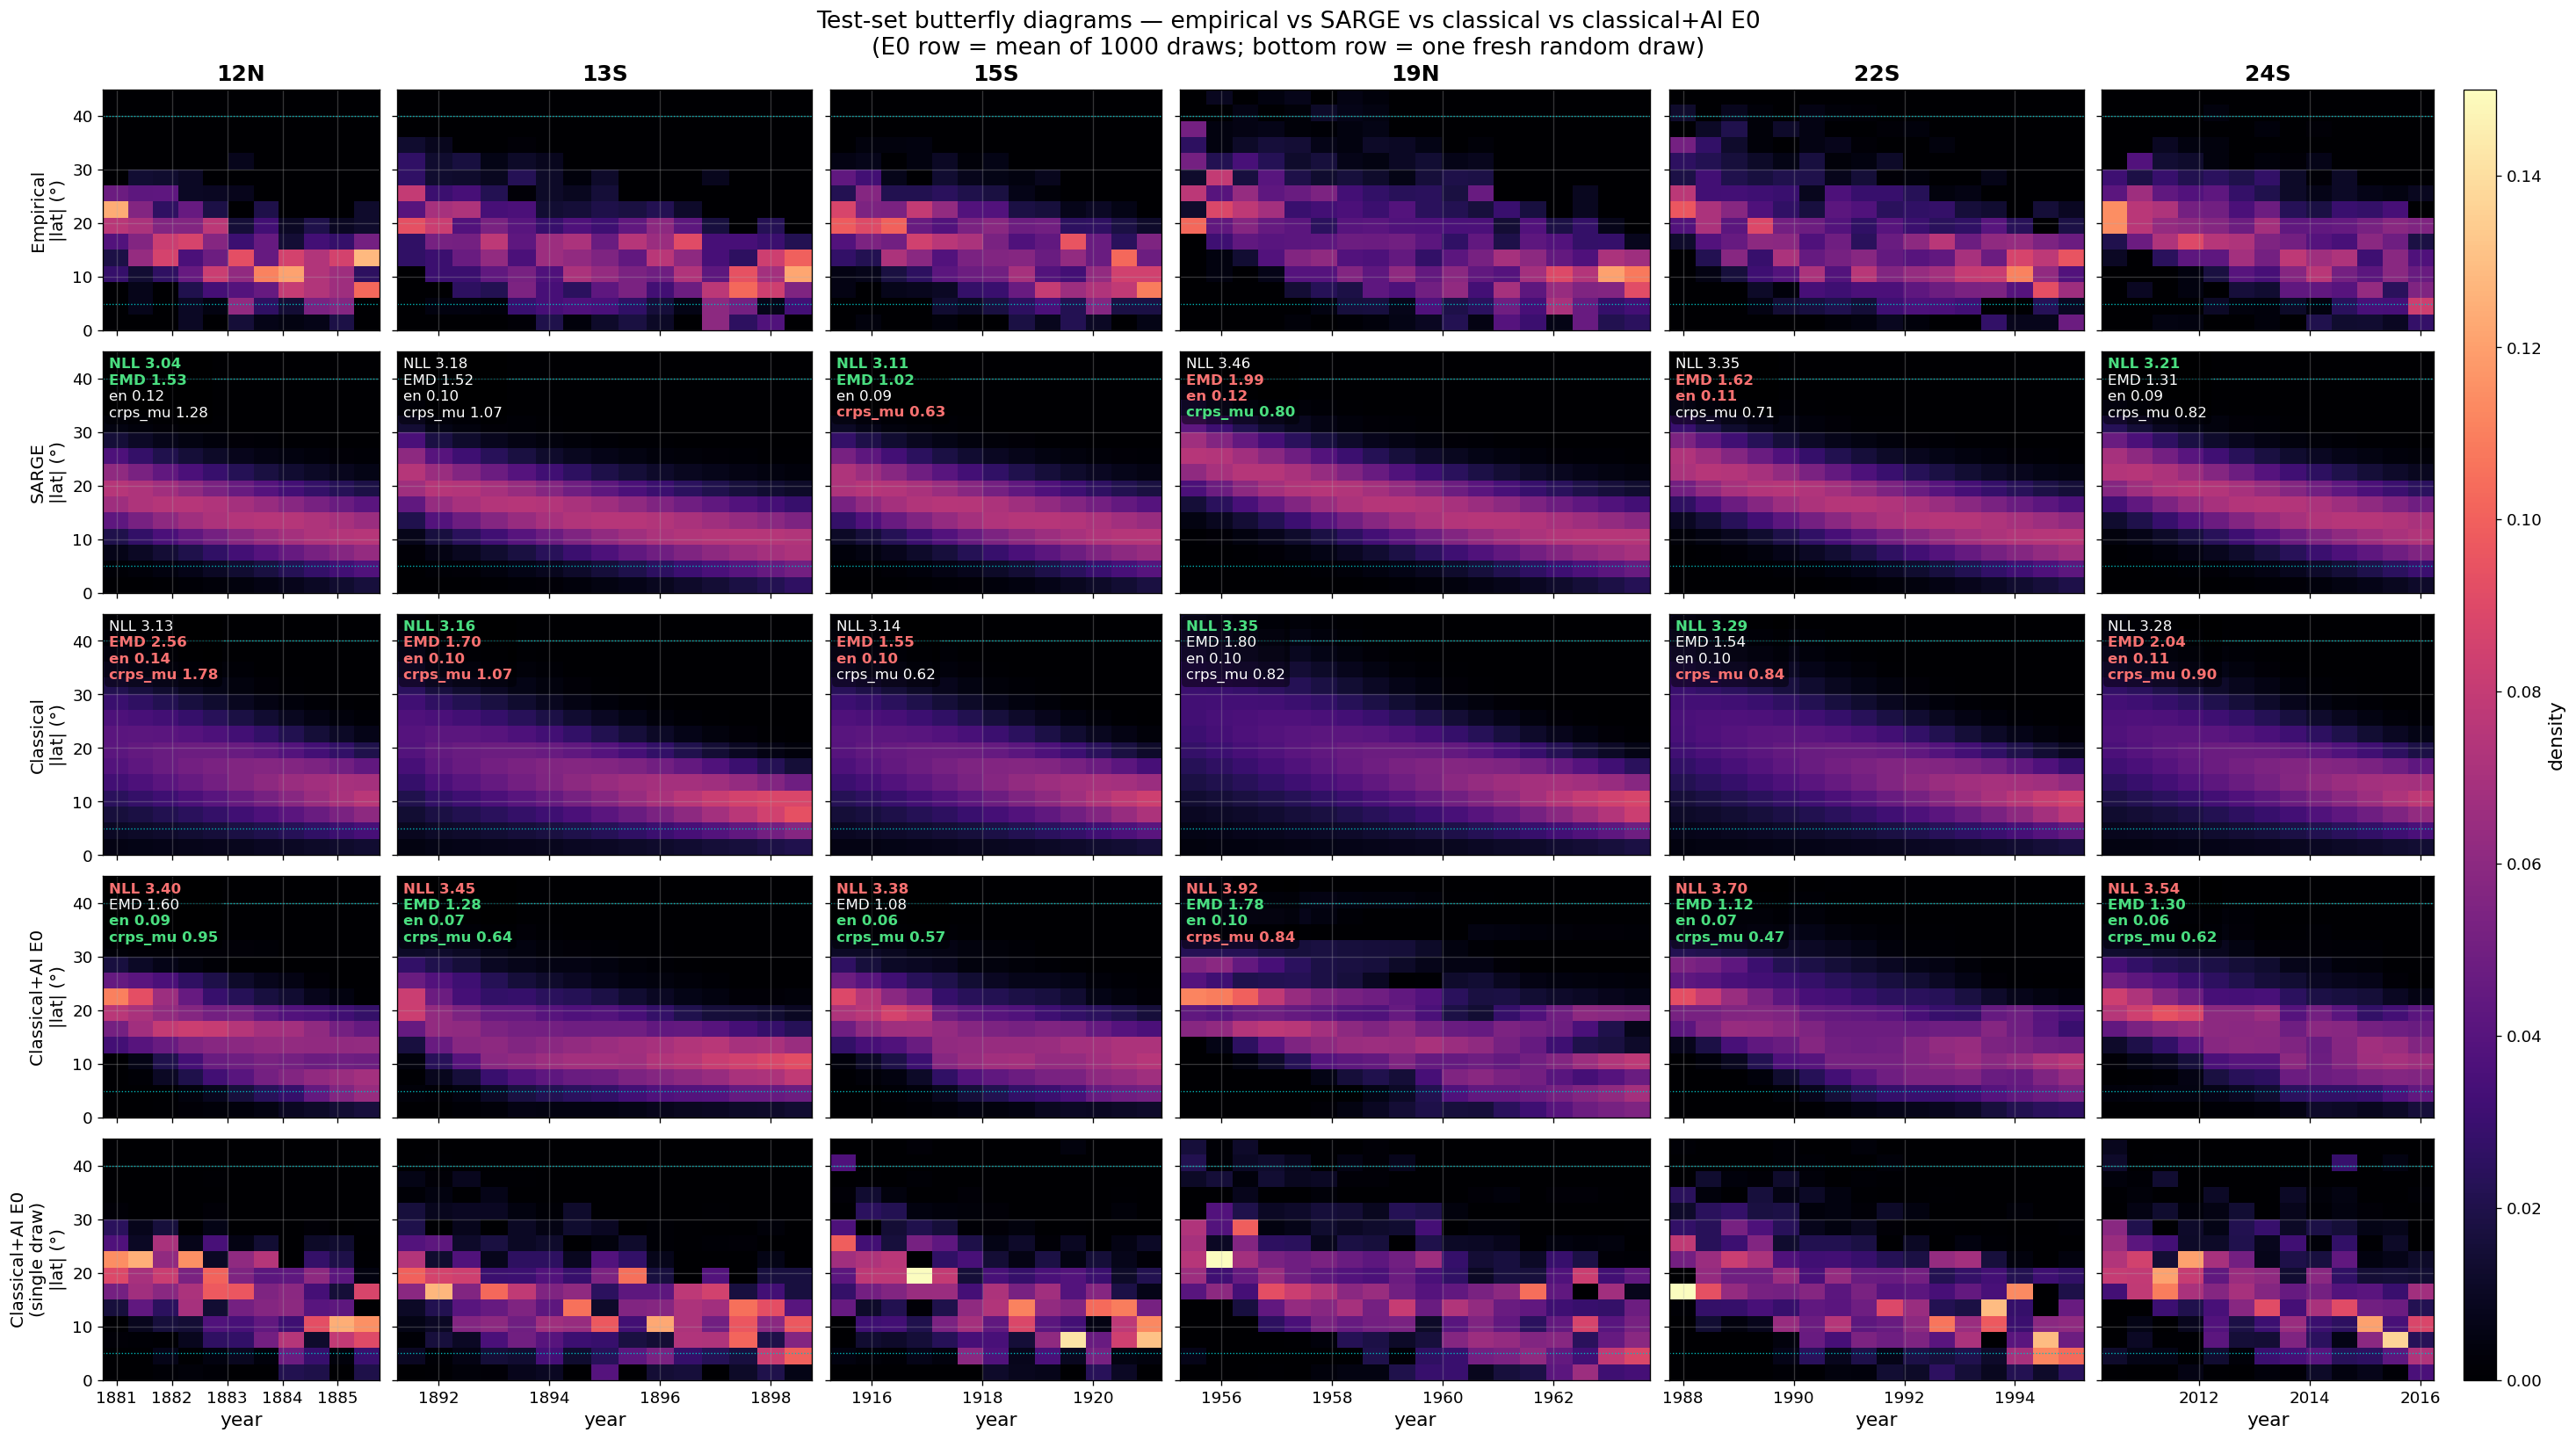

In [9]:
import time
from matplotlib.ticker import MaxNLocator
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, VPacker
vmax = 0.15
SINGLE_ROW = f"{AI_ROW} (single draw)"
YLAB = {"Empirical": "Empirical", "SARGE": "SARGE", "Classical": "Classical",
        AI_ROW: AI_SHORT,
        SINGLE_ROW: f"{AI_SHORT}\n(single draw)"}

# Roll ONE fresh reverse-diffusion realization per window (bottom row). Seeded
# from entropy so re-running THIS cell resamples a different draw every time.
torch.manual_seed(time.time_ns() % (2**31))
single_maps = {tag_of(hc): single_ai_map(hc) for hc in test_hcs}

fig_rows = MODEL_ROWS + [SINGLE_ROW]
nrows, ncols = len(fig_rows), len(test_hcs)
# Column widths proportional to each hemicycle's duration (years) so every
# x axis shares one year scale -> short cycles get thinner columns.
col_spans = [max(float(np.ptp(maps_by_hc[tag_of(hc)]["Classical"][1])), 0.5)
             if maps_by_hc[tag_of(hc)]["Classical"][1].size else 1.0
             for hc in test_hcs]
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(0.55 * sum(col_spans) + 2.0, 2.7 * nrows),
                         sharex="col", sharey=True, squeeze=False,
                         gridspec_kw={"width_ratios": col_spans},
                         layout="constrained")

_rank_colors = {tag_of(hc): metric_colors(tag_of(hc)) for hc in test_hcs}

im = None
for j, hc in enumerate(test_hcs):
    tg = tag_of(hc)
    for i, row in enumerate(fig_rows):
        ax = axes[i, j]
        m, t = single_maps[tg] if row == SINGLE_ROW else maps_by_hc[tg][row]
        if m.size and t.size:
            im = ax.imshow(m.T, origin="lower", aspect="auto", vmin=0, vmax=vmax,
                           extent=[t.min(), t.max(), LAT_BINS[0], LAT_BINS[-1]],
                           cmap="magma")
        ax.axhline(5,  color="c", ls=":", lw=0.8)
        ax.axhline(40, color="c", ls=":", lw=0.8)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        if i == 0:
            ax.set_title(tg, fontsize=15, fontweight="bold")
        if j == 0:
            ax.set_ylabel(f"{YLAB[row]}\n|lat| (°)", fontsize=12)
        if i == nrows - 1:
            ax.set_xlabel("year", fontsize=13)
        ax.tick_params(labelsize=11)
        # metric annotation on the scored model rows (not empirical / single-draw).
        # Green = best in this column, red = worst; all metrics are lower-is-better.
        if row in metrics_by_hc[tg]:
            draw_metric_box(ax, metrics_by_hc[tg][row], _rank_colors[tg][row])

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), aspect=40, pad=0.01)
cbar.set_label("density", fontsize=13)
cbar.ax.tick_params(labelsize=11)
fig.suptitle("Test-set butterfly diagrams — empirical vs SARGE vs classical vs classical+AI\n"
             f"({SHOWCASE_NAME} row = mean of {K} draws; bottom row = one fresh random draw)",
             fontsize=16)
try:
    fig.get_layout_engine().set(w_pad=0.02, h_pad=0.02, wspace=0.03, hspace=0.04)
except Exception:
    pass
plt.show()

---
## Area-weighted view — density weighted across the whole cycle

The grid above normalizes every 6-month window independently, so cycle minimum and cycle
maximum look equally bright. Here we instead weight each window's latitude density by the
**smoothed total sunspot area** at that window (`area_smoothed` from the conditioning
parquet) and renormalize each hemicycle so the whole cycle integrates to 1. The panels now
show *where the activity actually concentrates*: the cycle-maximum windows dominate, the way
the empirical butterfly's bright core does. The same area weight is applied to all four rows
so the comparison stays apples-to-apples.

{'nll': np.float64(3.038883293153175), 'emd': 1.5264799071111106, 'energy': 0.11580185166191241, 'crps_mu': 1.2845636583373503}
{'nll': np.float64(3.1301596713132978), 'emd': 2.562396599523589, 'energy': 0.13897634962859373, 'crps_mu': 1.7846976591066477}
{'nll': 3.4049795691240634, 'emd': 1.60253783316856, 'energy': 0.08939620608600948, 'crps_mu': 0.9534242202431422}
{'nll': np.float64(3.1819036940889487), 'emd': 1.5246914495112562, 'energy': 0.1006148807673099, 'crps_mu': 1.0657054322219899}
{'nll': np.float64(3.1558834155724185), 'emd': 1.7041983816920623, 'energy': 0.10109416194636937, 'crps_mu': 1.0684518299668526}
{'nll': 3.4493249130105594, 'emd': 1.2756530830559605, 'energy': 0.070517682982344, 'crps_mu': 0.6377417496924607}
{'nll': np.float64(3.106687051007035), 'emd': 1.0185820324721473, 'energy': 0.08952566913919989, 'crps_mu': 0.6256453429139991}
{'nll': np.float64(3.1416079252414204), 'emd': 1.554894156550643, 'energy': 0.10014489104437363, 'crps_mu': 0.617813986615801}
{'

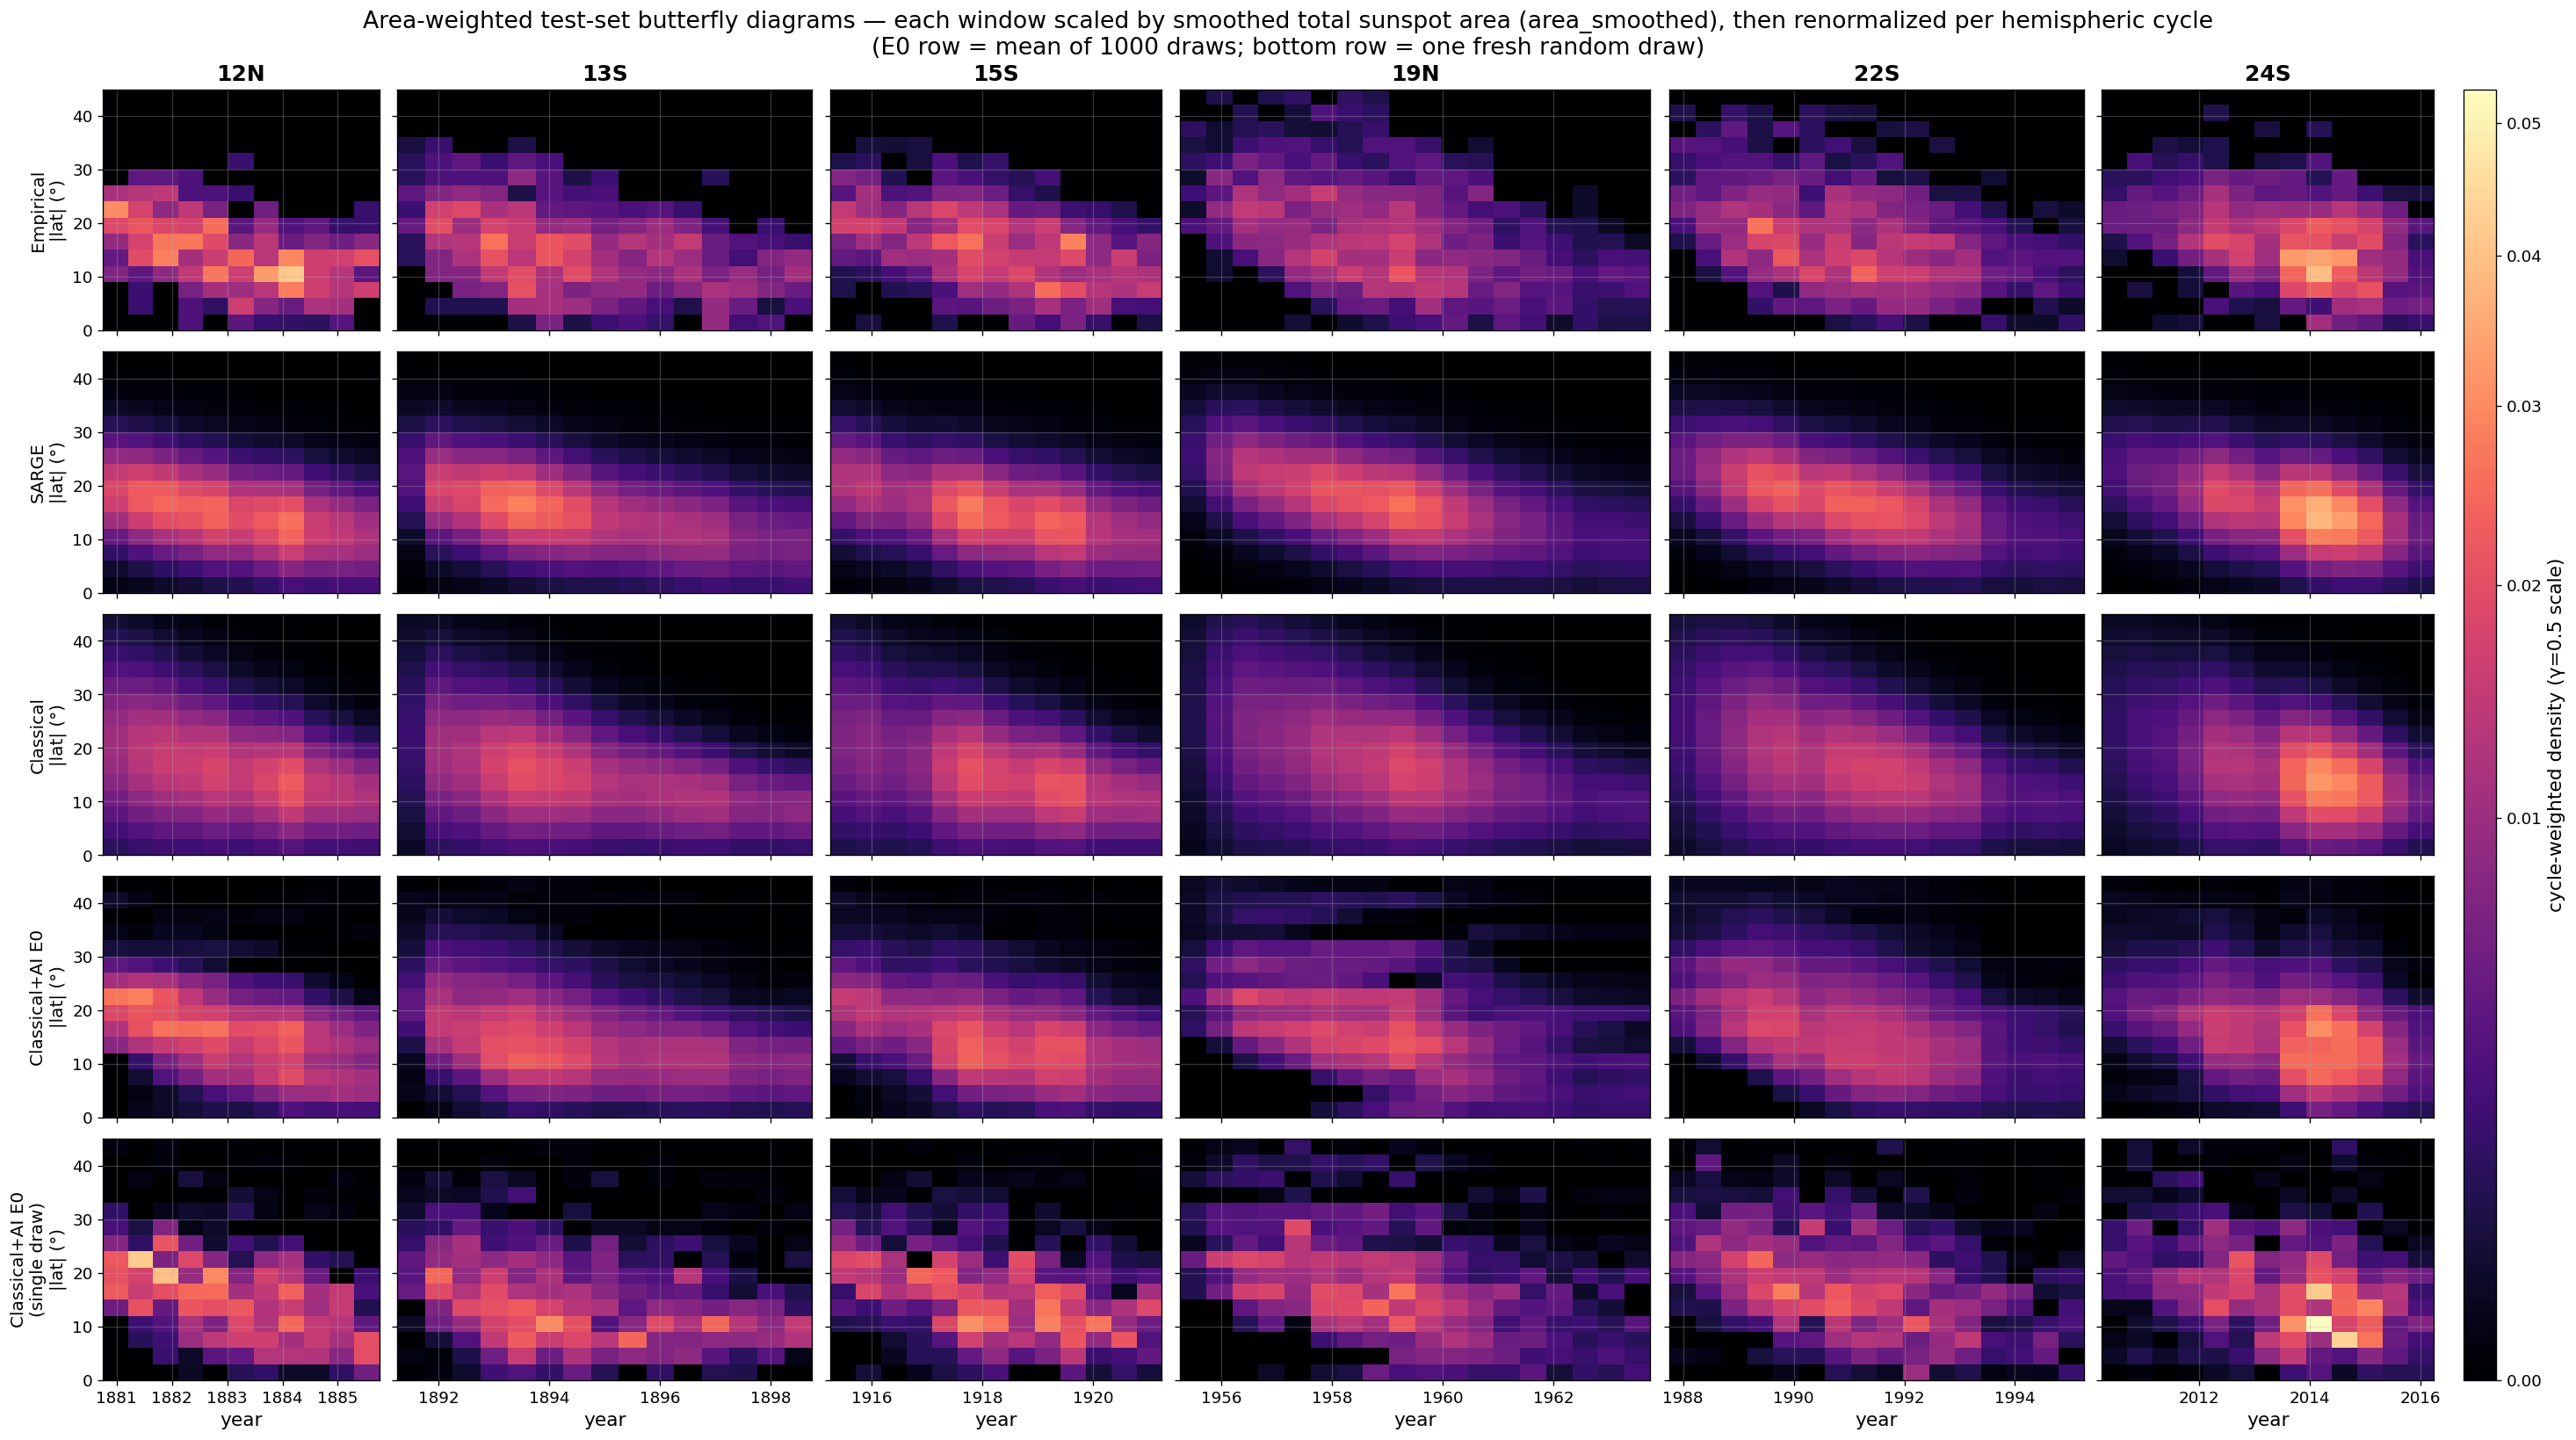

In [ ]:
from matplotlib.colors import PowerNorm
from matplotlib.ticker import MaxNLocator
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, VPacker
import time

# Which metrics get annotated on each panel of THIS figure. Any subset of the
# keys in METRIC_KEYS ("nll", "emd", "energy", "crps_mu"), in display order.
# Ranking colours are still computed over all four, so green/red keep meaning.
SHOW_METRICS = ["nll", "emd"]
_shown_metrics = [(k, lab) for k, lab in METRIC_KEYS if k in SHOW_METRICS]

SINGLE_ROW = f"{AI_ROW} (single draw)"
YLAB = {"Empirical": "Empirical", "SARGE": "SARGE", "Classical": "Classical",
        AI_ROW: AI_SHORT,
        SINGLE_ROW: f"{AI_SHORT}\n(single draw)"}
# Fresh single reverse-diffusion realization every run (bottom row).
torch.manual_seed(time.time_ns() % (2**31))
single_maps = {tag_of(hc): single_ai_map(hc) for hc in test_hcs}

# Per-window weight = smoothed total sunspot area from the conditioning parquet.
_t0_area = {(int(c), str(h)): float(classical.lookup_t0(int(c), h))
            for (c, h) in classical.known_hemicycles()}
_area_recs = {}
for _, r in windows_v2_full.iterrows():
    key = (int(r["cycle"]), str(r["hemisphere"]))
    if key in _t0_area:
        _area_recs.setdefault(key, []).append(
            (float(r["tau_center"]) + _t0_area[key], float(r["area_smoothed"])))

def area_weight(cyc, hemi, decimal_year):
    """Smoothed total sunspot area (MSH) nearest to a window center, or nan."""
    arr = _area_recs.get((int(cyc), str(hemi)))
    if not arr:
        return np.nan
    yrs  = np.array([a[0] for a in arr])
    vals = np.array([a[1] for a in arr])
    return float(vals[np.argmin(np.abs(yrs - decimal_year))])

def weighted_map(hc, m, t):
    """Area-weight each window column, then renormalize the hemicycle to unit mass."""
    if not (m.size and t.size):
        return m
    w = np.array([area_weight(hc["cycle"], hc["hemisphere"], float(tt)) for tt in t])
    w = np.where(np.isfinite(w) & (w > 0), w, 0.0)
    wm = m * w[:, None]
    tot = wm.sum()
    return wm / tot if tot > 0 else wm

# Precompute weighted maps + a shared color scale.
area_rows = MODEL_ROWS + [SINGLE_ROW]
wmaps_by_hc, _allvals = {}, []
for hc in test_hcs:
    tg = tag_of(hc)
    wmaps_by_hc[tg] = {}
    for row in area_rows:
        m, t = single_maps[tg] if row == SINGLE_ROW else maps_by_hc[tg][row]
        wm = weighted_map(hc, m, t)
        wmaps_by_hc[tg][row] = (wm, t)
        if wm.size:
            _allvals.append(wm.ravel())
# The weighted density is heavily right-skewed (a few bright cycle-max cells,
# most cells ~0). A linear scale would clip/saturate that core, so we use the
# TRUE global max (no clipping) with a gamma=0.5 PowerNorm to lift the mid-tones
# and reveal the full wing structure. Colorbar is therefore perceptual, not linear.
gmax_w = float(np.concatenate(_allvals).max()) if _allvals else 1.0
_norm_w = PowerNorm(gamma=0.5, vmin=0.0, vmax=gmax_w)

nrows, ncols = len(area_rows), len(test_hcs)
# Column widths proportional to each hemicycle's duration (years), so every
# x axis shares one year scale.
col_spans = [max(float(np.ptp(wmaps_by_hc[tag_of(hc)]["Classical"][1])), 0.5)
             if wmaps_by_hc[tag_of(hc)]["Classical"][1].size else 1.0
             for hc in test_hcs]
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(0.55 * sum(col_spans) + 2.0, 2.7 * nrows),
                         sharex="col", sharey=True, squeeze=False,
                         gridspec_kw={"width_ratios": col_spans},
                         layout="constrained")
_rank_colors = {tag_of(hc): metric_colors(tag_of(hc)) for hc in test_hcs}

im = None
for j, hc in enumerate(test_hcs):
    tg = tag_of(hc)
    for i, row in enumerate(area_rows):
        ax = axes[i, j]
        wm, t = wmaps_by_hc[tg][row]
        if wm.size and t.size:
            im = ax.imshow(wm.T, origin="lower", aspect="auto", norm=_norm_w,
                           extent=[t.min(), t.max(), LAT_BINS[0], LAT_BINS[-1]],
                           cmap="magma")
        # ax.axhline(5,  color="c", ls=":", lw=0.8)
        # ax.axhline(40, color="c", ls=":", lw=0.8)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        if i == 0:
            ax.set_title(tg, fontsize=15, fontweight="bold")
        if j == 0:
            ax.set_ylabel(f"{YLAB[row]}\n|lat| (°)", fontsize=12)
        if i == nrows - 1:
            ax.set_xlabel("year", fontsize=13)
        ax.tick_params(labelsize=11)
        # metric annotation on the scored model rows (not empirical / single-draw).
        # Green = best in this column, red = worst; all metrics are lower-is-better.
        if row in metrics_by_hc[tg]:
            draw_metric_box(ax, metrics_by_hc[tg][row], _rank_colors[tg][row],
                            metric_keys=_shown_metrics)

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), aspect=40, pad=0.01)
cbar.set_label("cycle-weighted density (γ=0.5 scale)", fontsize=13)
cbar.ax.tick_params(labelsize=11)
fig.suptitle("Area-weighted test-set butterfly diagrams — each window scaled by smoothed "
             "total sunspot area (area_smoothed), then renormalized per hemispheric cycle\n"
             f"({SHOWCASE_NAME} row = mean of {K} draws; bottom row = one fresh random draw)", fontsize=16)
try:
    fig.get_layout_engine().set(w_pad=0.02, h_pad=0.02, wspace=0.03, hspace=0.04)
except Exception:
    pass
plt.show()

---
## Butterfly realizations — sampled groups over the density

Same 5×6 layout and area-weighted (γ=0.5) density background as above, but each panel now
also shows **one realization**: for every 6-month window we draw the **same number of groups
that were observed** and place them at the **real observation dates**. The **Empirical** row
shows the actual observed groups; **SARGE** / **Classical** draw latitudes from their
continuous N(μ, σ); the two **`base_cat`** rows draw from their 15-bin residual densities — the
**mean-of-K** density (4th row) and one fresh **single-draw** density (bottom row), the two
different generated distributions. Re-run the cell to resample everything.

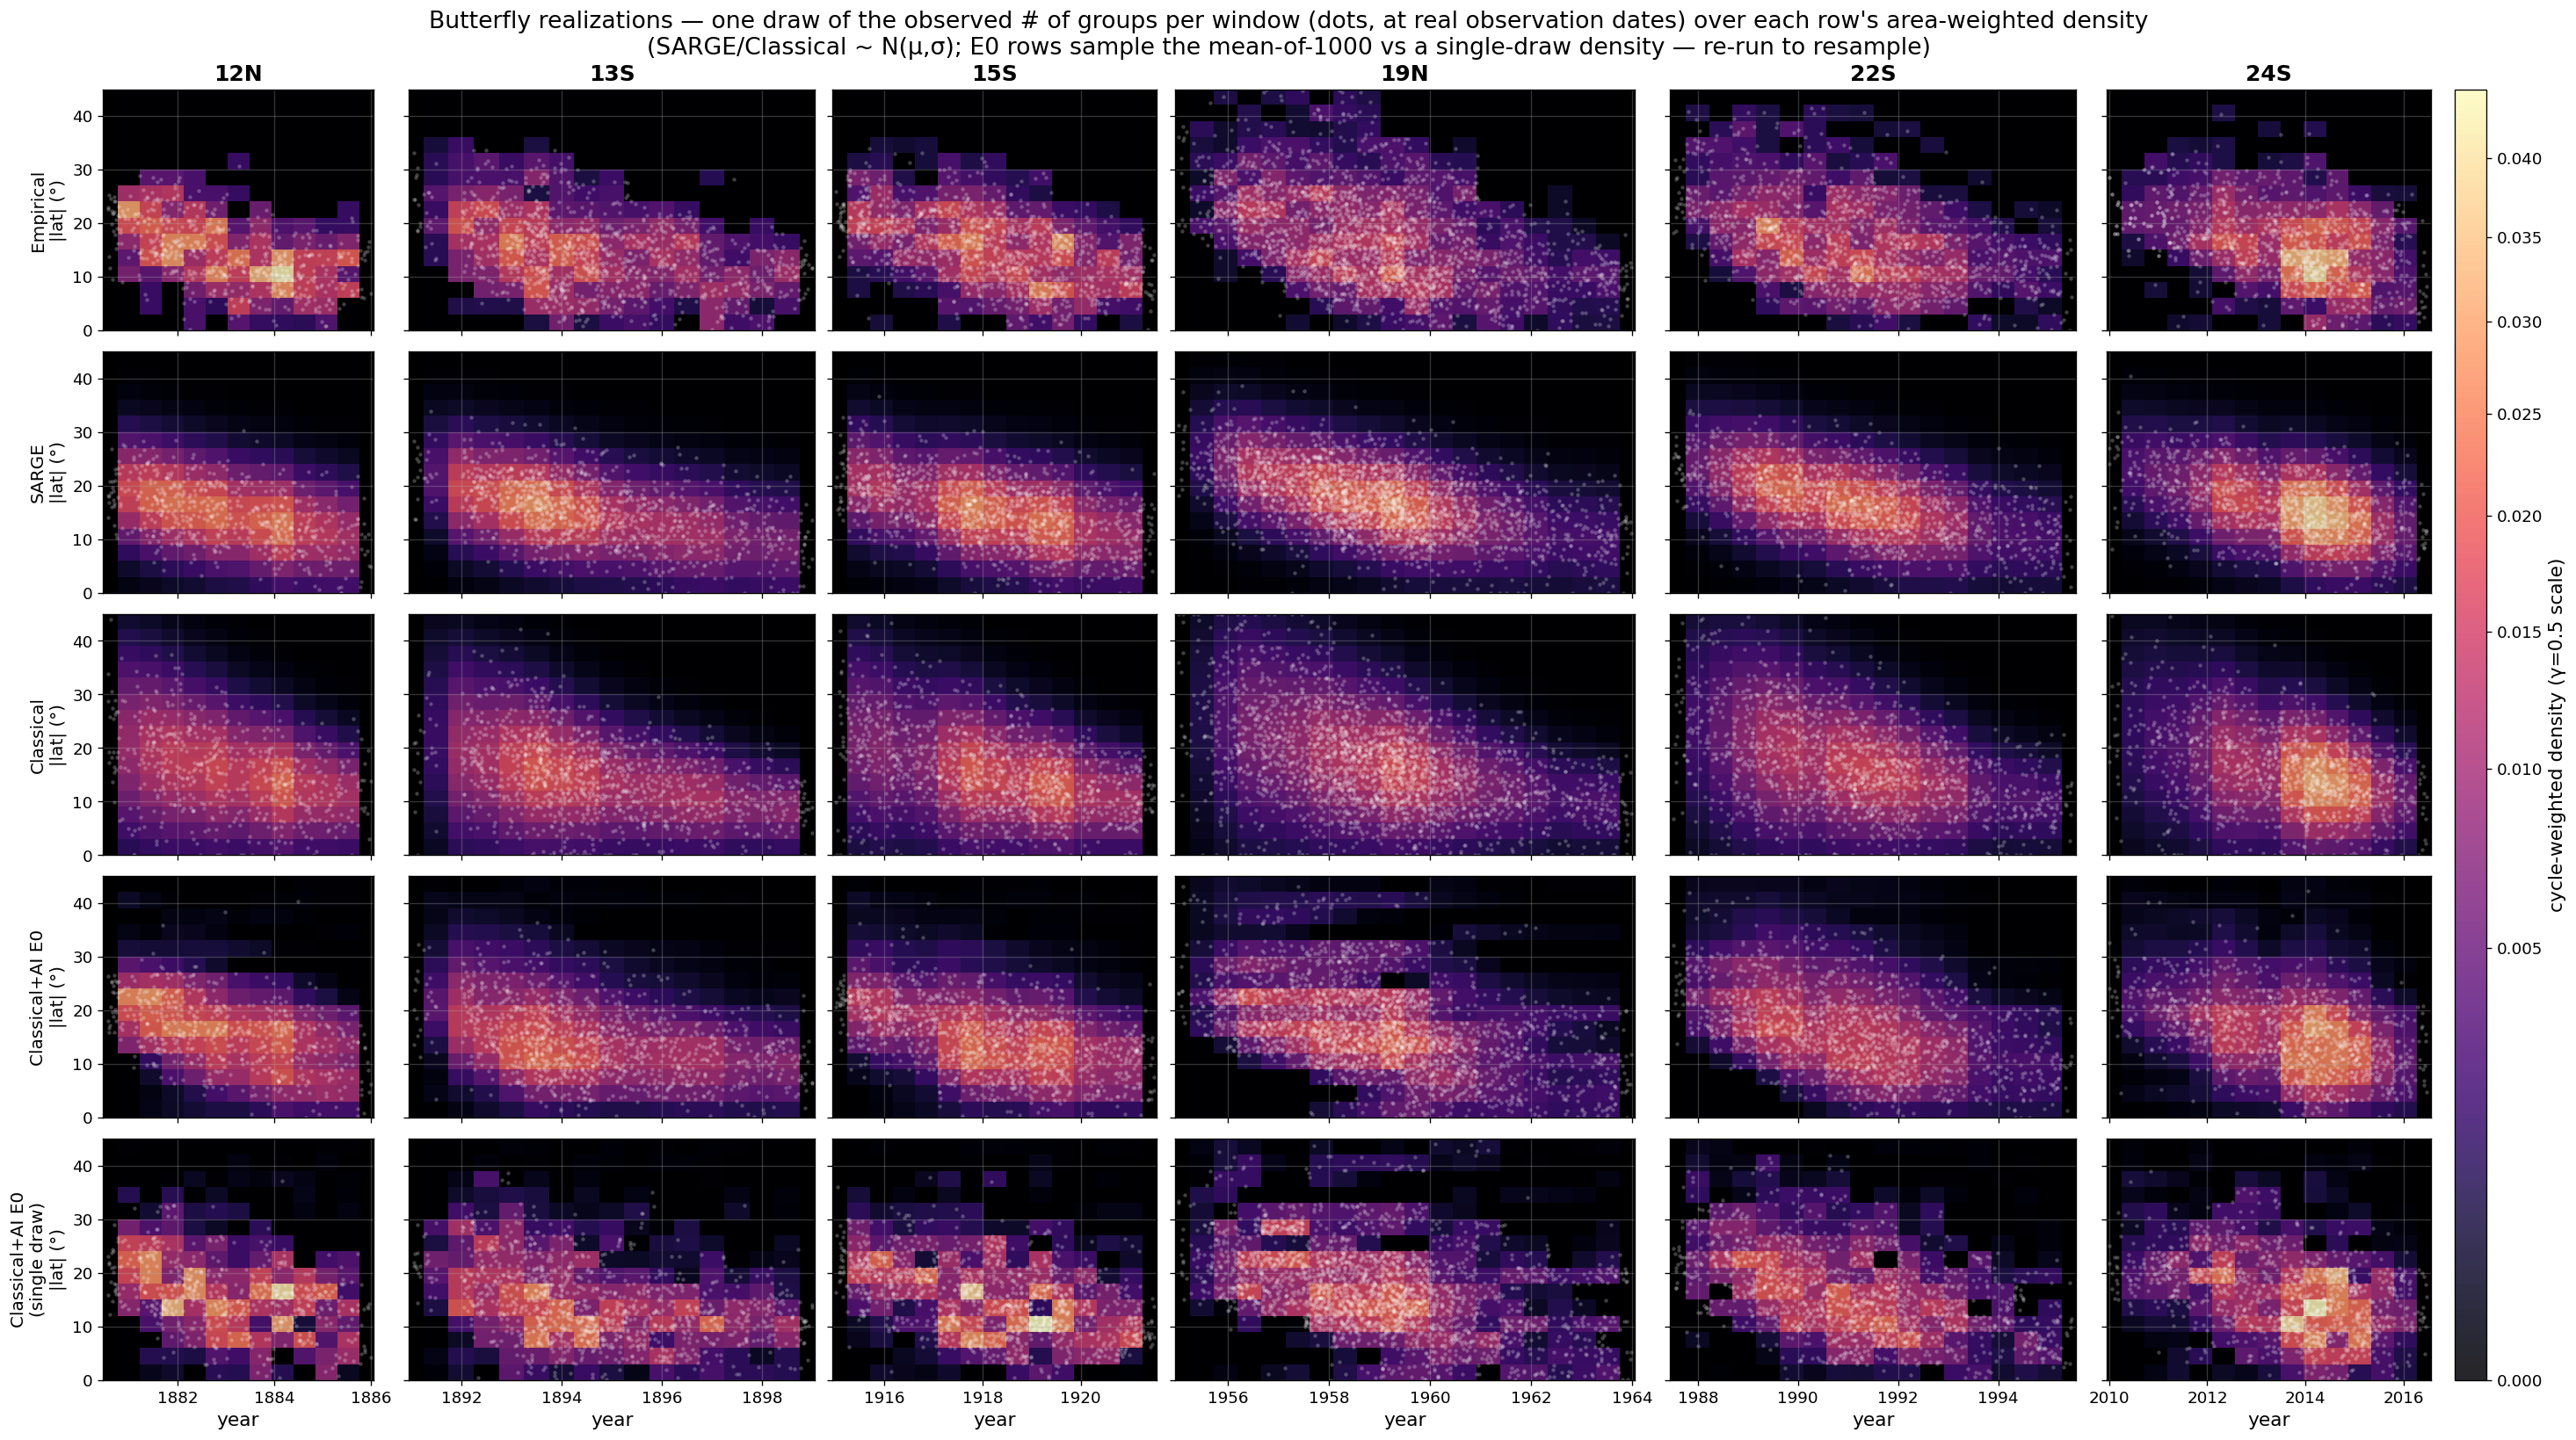

In [11]:
# ---- Butterfly realizations (scatter) over the area-weighted density ----
# Overlay: each panel shows its row's area-weighted probability field (faded) with
# ONE realization on top — the same number of groups as were OBSERVED in each
# 6-month window, placed at the real observation dates. Empirical shows the actual
# observed groups; SARGE/Classical draw from their continuous N(mu, sigma); the two
# The AI rows draw from their 15-bin residual densities — the mean-of-K density
# (2nd-from-bottom) and one fresh single-draw density (bottom). Re-run to resample.
import time
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import PowerNorm

rng = np.random.default_rng()                       # fresh draws every run
torch.manual_seed(time.time_ns() % (2**31))

SINGLE_ROW = f"{AI_ROW} (single draw)"
scatter_rows = MODEL_ROWS + [SINGLE_ROW]
YLAB = {"Empirical": "Empirical", "SARGE": "SARGE", "Classical": "Classical",
        AI_ROW: AI_SHORT, SINGLE_ROW: f"{AI_SHORT}\n(single draw)"}
# PT = dict(s=7, marker="o", linewidths=0, color="#19e6ff", alpha=0.45)   # low-alpha scatter
PT = dict(s=7, marker="o", linewidths=0, color="#ffffff", alpha=0.25)   # low-alpha scatter

# Fresh single reverse-diffusion realization -> the bottom row's distribution.
single_maps = {tag_of(hc): single_ai_map(hc) for hc in test_hcs}

# Raw catalog for true observation dates (same filtering as build_eval_hemicycles).
_raw = pd.read_csv(paths["raw_csv"])
_raw["date"]         = pd.to_datetime(_raw[["year", "month", "day"]])
_raw = _raw.dropna(subset=["CYCLE"]).copy()
_raw["CYCLE"]        = _raw["CYCLE"].astype(int)
_raw["abs_lat"]      = _raw["latitude"].abs()
_raw["hemisphere"]   = np.where(_raw["latitude"] >= 0, "north", "south")
_raw["decimal_year"] = _raw["date"].dt.year + _raw["date"].dt.dayofyear / 365.25

def observed_groups(cyc, hemi, center_decimal):
    """(times, |lat|) of observed groups in the 6-month window around a center."""
    yr = int(np.floor(center_decimal))
    if center_decimal - yr < 0.5:
        ws, we = pd.Timestamp(yr, 1, 1), pd.Timestamp(yr, 7, 1)
    else:
        ws, we = pd.Timestamp(yr, 7, 1), pd.Timestamp(yr + 1, 1, 1)
    sel = _raw[(_raw["CYCLE"] == int(cyc)) & (_raw["hemisphere"] == hemi)
               & (_raw["date"] >= ws) & (_raw["date"] < we)]
    return sel["decimal_year"].to_numpy(), sel["abs_lat"].to_numpy()

def _draw_bins(dens, n):
    """Draw n latitudes from a 15-bin density (bin center + uniform jitter)."""
    p = np.maximum(np.asarray(dens, float), 0.0)
    p = p / p.sum() if p.sum() > 0 else np.full(len(BIN_CENTERS), 1.0 / len(BIN_CENTERS))
    idx = rng.choice(len(BIN_CENTERS), size=n, p=p)
    return np.clip(BIN_CENTERS[idx] + rng.uniform(-BIN_WIDTH / 2, BIN_WIDTH / 2, n), 0, 45)

# Area-weighted (gamma=0.5) density backgrounds + one realization per (row, hemicycle).
bg_by_hc, pts_by_hc, _bgvals = {}, {}, []
for hc in test_hcs:
    tg = tag_of(hc)
    t_ref = maps_by_hc[tg]["Classical"][1]
    blk_by_t = {float(b["center_decimal"]): b for b in hc["blocks"]}
    dmaps = {"Empirical":         maps_by_hc[tg]["Empirical"][0],
             "SARGE":             maps_by_hc[tg]["SARGE"][0],
             "Classical":         maps_by_hc[tg]["Classical"][0],
             AI_ROW: maps_by_hc[tg][AI_ROW][0],
             SINGLE_ROW:          single_maps[tg][0]}
    bg_by_hc[tg] = {}
    for row, dm in dmaps.items():
        wm = weighted_map(hc, dm, t_ref)
        bg_by_hc[tg][row] = (wm, t_ref)
        if wm.size:
            _bgvals.append(wm.ravel())

    rows_pts = {r: ([], []) for r in scatter_rows}
    for i, t in enumerate(t_ref):
        blk = blk_by_t[float(t)]
        times, obs_lats = observed_groups(hc["cycle"], hc["hemisphere"], float(t))
        n = len(times)
        if n == 0:
            continue
        A = hc["amplitude"]
        _, mu_s, sig_s = sarge_bin_density(float(t), hc["cycle"], hc["hemisphere"])
        mu_c = float(classical.mu(blk["tau"])); sig_c = float(classical.sigma(mu_c, A))
        draws = {
            "Empirical":         obs_lats,
            "SARGE":             np.clip(rng.normal(mu_s, sig_s, n), 0, 45),
            "Classical":         np.clip(rng.normal(mu_c, sig_c, n), 0, 45),
            AI_ROW: _draw_bins(maps_by_hc[tg][AI_ROW][0][i], n),
            SINGLE_ROW:          _draw_bins(single_maps[tg][0][i], n),
        }
        for r in scatter_rows:
            rows_pts[r][0].append(times); rows_pts[r][1].append(draws[r])
    pts_by_hc[tg] = {r: (np.concatenate(xy[0]) if xy[0] else np.array([]),
                         np.concatenate(xy[1]) if xy[1] else np.array([]))
                     for r, xy in rows_pts.items()}

gmax_w = float(np.concatenate(_bgvals).max()) if _bgvals else 1.0
_norm_w = PowerNorm(gamma=0.5, vmin=0.0, vmax=gmax_w)

nrows, ncols = len(scatter_rows), len(test_hcs)
col_spans = [max(float(np.ptp(maps_by_hc[tag_of(hc)]["Classical"][1])), 0.5)
             if maps_by_hc[tag_of(hc)]["Classical"][1].size else 1.0
             for hc in test_hcs]
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(0.55 * sum(col_spans) + 2.0, 2.7 * nrows),
                         sharex="col", sharey=True, squeeze=False,
                         gridspec_kw={"width_ratios": col_spans},
                         layout="constrained")
im = None
for j, hc in enumerate(test_hcs):
    tg = tag_of(hc)
    for i, row in enumerate(scatter_rows):
        ax = axes[i, j]
        ax.set_facecolor("black")   # so faded density keeps its dark end and the dots pop
        wm, t = bg_by_hc[tg][row]
        if wm.size and t.size:
            im = ax.imshow(wm.T, origin="lower", aspect="auto", norm=_norm_w, alpha=0.85,
                           extent=[t.min(), t.max(), LAT_BINS[0], LAT_BINS[-1]], cmap="magma")
        px, py = pts_by_hc[tg][row]
        if px.size:
            ax.scatter(px, py, **PT)
        ax.set_ylim(LAT_BINS[0], LAT_BINS[-1])
        if t.size:
            ax.set_xlim(t.min() - 0.3, t.max() + 0.3)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        if i == 0:
            ax.set_title(tg, fontsize=15, fontweight="bold")
        if j == 0:
            ax.set_ylabel(f"{YLAB[row]}\n|lat| (°)", fontsize=12)
        if i == nrows - 1:
            ax.set_xlabel("year", fontsize=13)
        ax.tick_params(labelsize=11)

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), aspect=40, pad=0.01)
cbar.set_label("cycle-weighted density (γ=0.5 scale)", fontsize=13)
cbar.ax.tick_params(labelsize=11)
fig.suptitle("Butterfly realizations — one draw of the observed # of groups per window "
             "(dots, at real observation dates) over each row's area-weighted density\n"
             f"(SARGE/Classical ~ N(μ,σ); {SHOWCASE_NAME} rows sample the mean-of-{K} vs a single-draw "
             "density — re-run to resample)", fontsize=16)
try:
    fig.get_layout_engine().set(w_pad=0.02, h_pad=0.02, wspace=0.03, hspace=0.04)
except Exception:
    pass
plt.show()

---
## Realizations vs the observed density (common backdrop)

Identical to the previous figure, but **every** row's backdrop is the **observed (empirical)** area-weighted density — so each model's realization (dots) is read against the same real butterfly field. Re-run to resample.

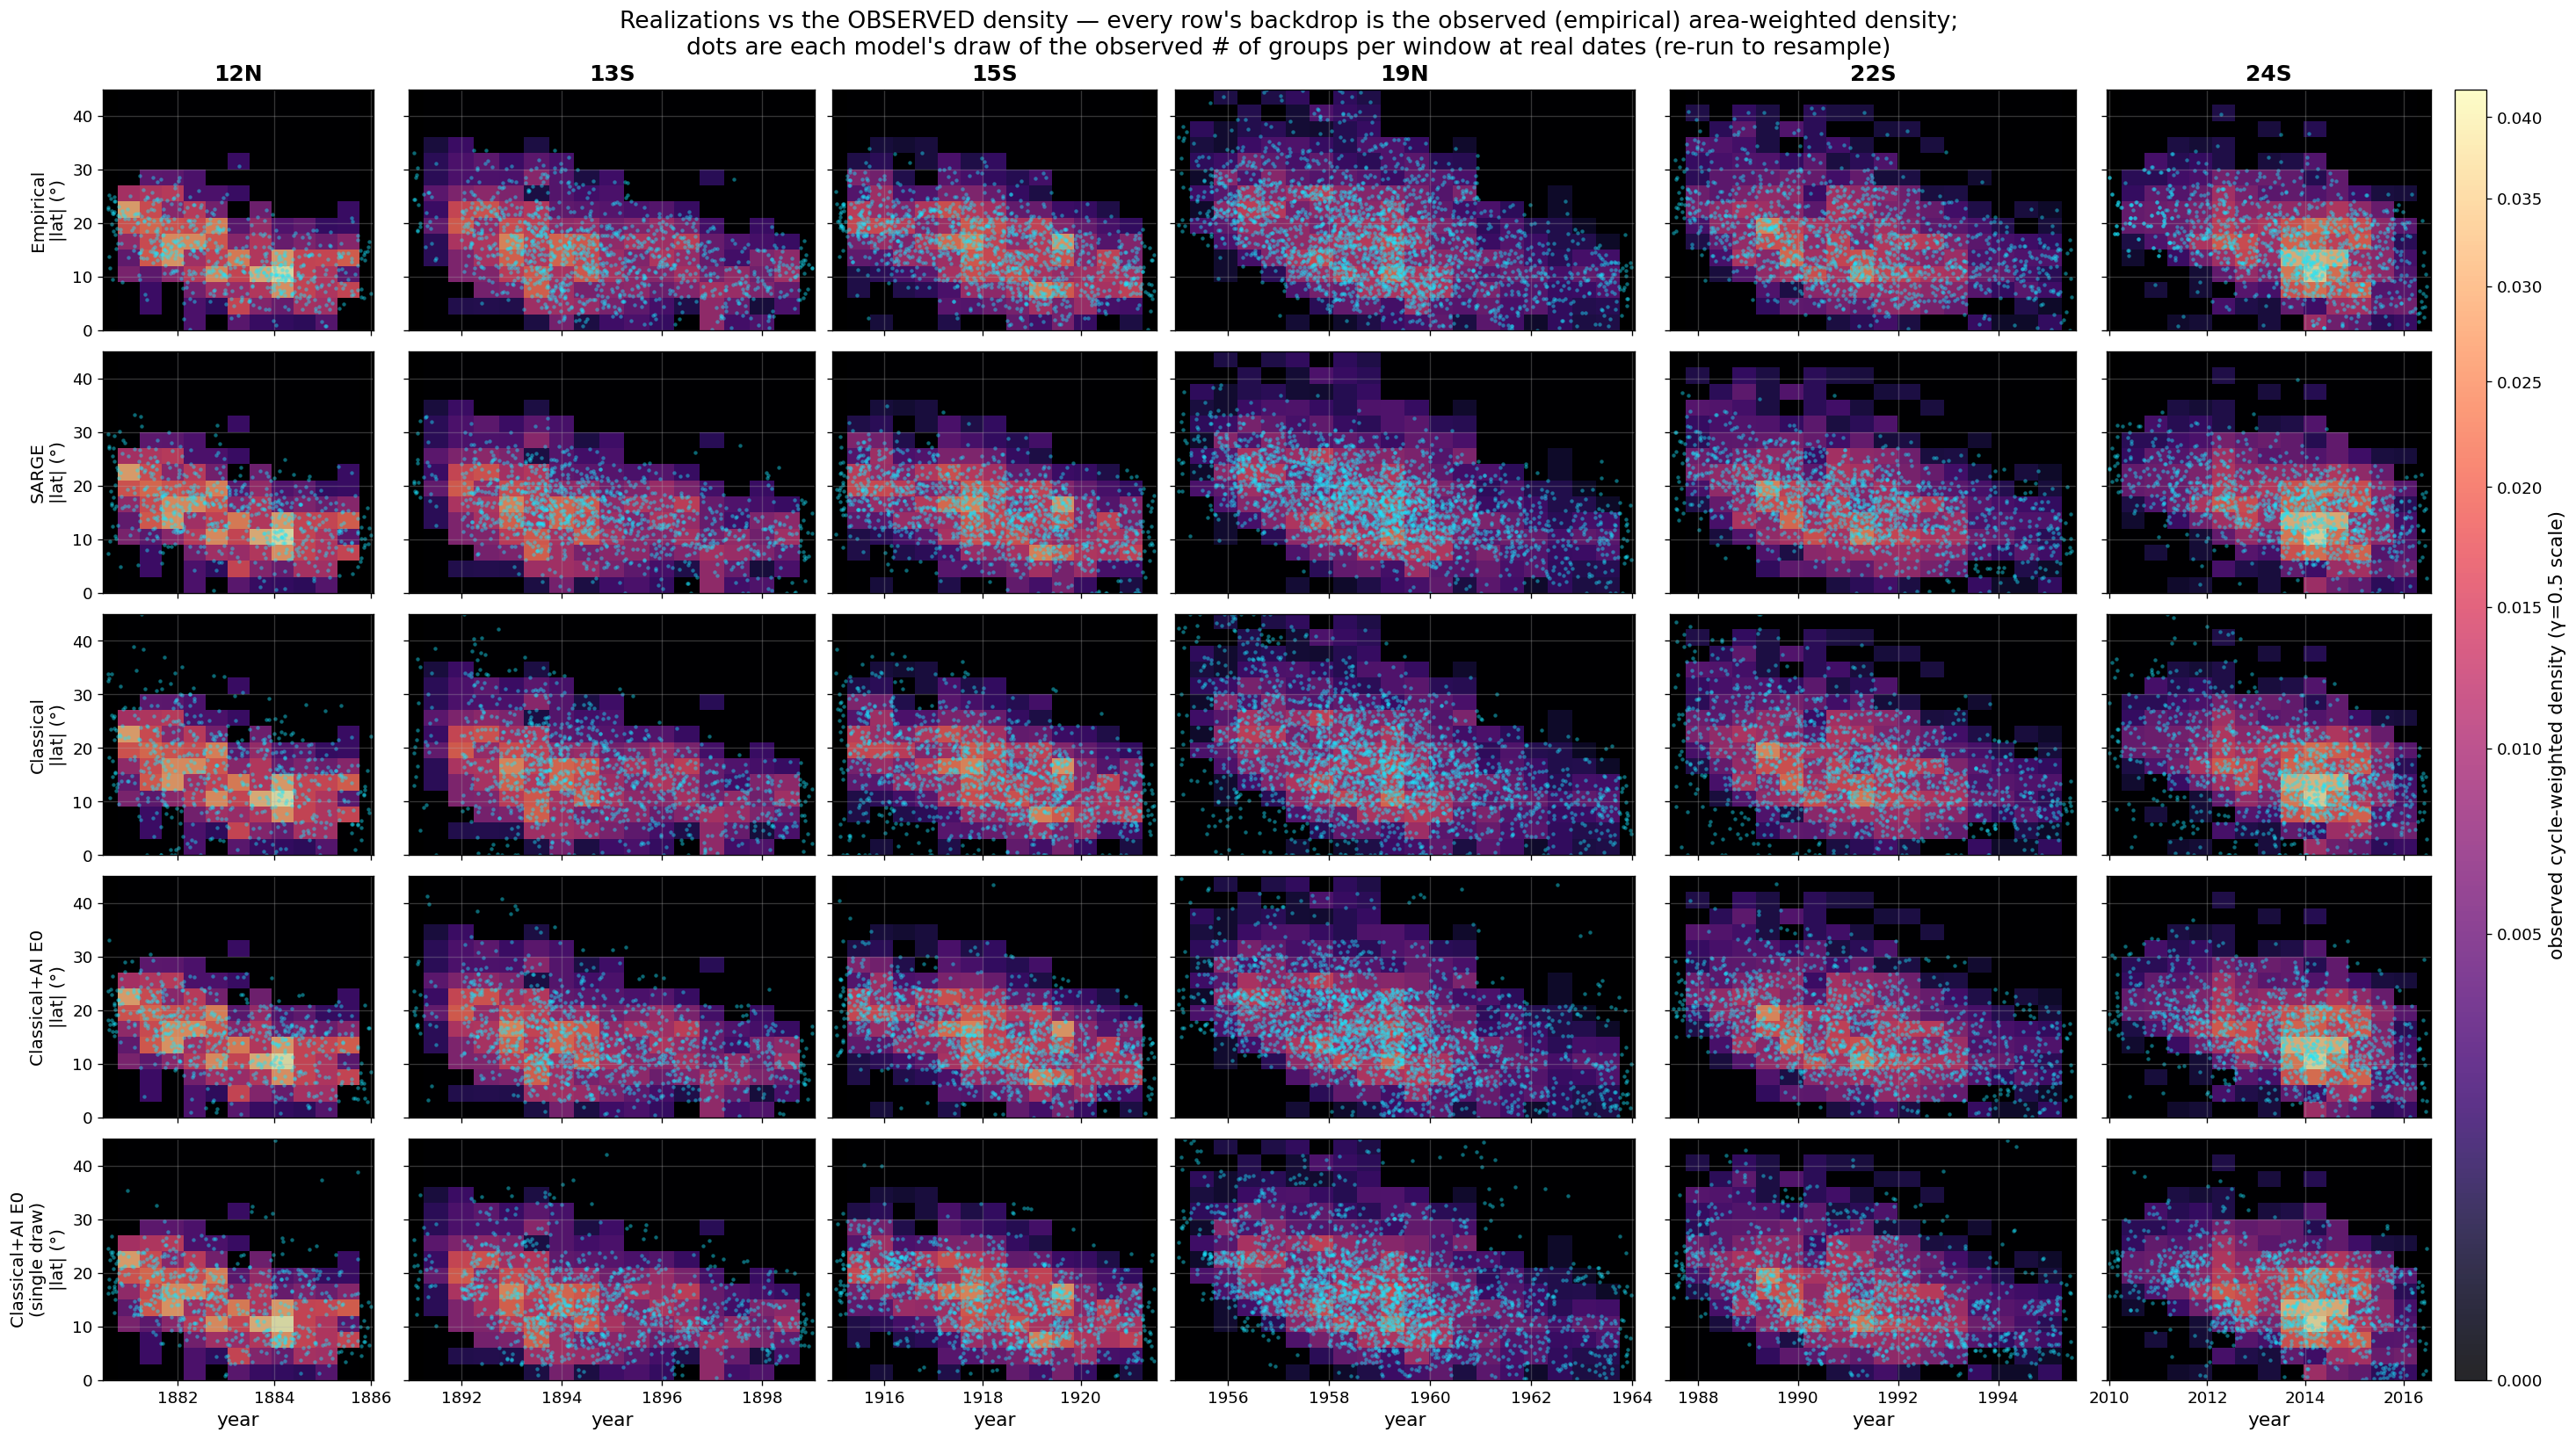

In [12]:
# ---- Realizations over a COMMON background: the OBSERVED (empirical) density ----
# Same per-row draws as the previous figure, but every row's backdrop is now the
# observed area-weighted density, so each model's realization is read against the
# same empirical field. Re-run to resample. (Reuses observed_groups / _draw_bins /
# _raw / weighted_map defined in the previous cell.)
import time
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import PowerNorm

rng = np.random.default_rng()
torch.manual_seed(time.time_ns() % (2**31))

SINGLE_ROW = f"{AI_ROW} (single draw)"
scatter_rows = MODEL_ROWS + [SINGLE_ROW]
YLAB = {"Empirical": "Empirical", "SARGE": "SARGE", "Classical": "Classical",
        AI_ROW: AI_SHORT, SINGLE_ROW: f"{AI_SHORT}\n(single draw)"}
PT = dict(s=7, marker="o", linewidths=0, color="#19e6ff", alpha=0.45)

single_maps = {tag_of(hc): single_ai_map(hc) for hc in test_hcs}

# Common background = the OBSERVED (empirical) area-weighted density per hemicycle.
emp_bg, pts_by_hc, _bgvals = {}, {}, []
for hc in test_hcs:
    tg = tag_of(hc)
    t_ref = maps_by_hc[tg]["Classical"][1]
    blk_by_t = {float(b["center_decimal"]): b for b in hc["blocks"]}
    wm = weighted_map(hc, maps_by_hc[tg]["Empirical"][0], t_ref)
    emp_bg[tg] = (wm, t_ref)
    if wm.size:
        _bgvals.append(wm.ravel())

    rows_pts = {r: ([], []) for r in scatter_rows}
    for i, t in enumerate(t_ref):
        blk = blk_by_t[float(t)]
        times, obs_lats = observed_groups(hc["cycle"], hc["hemisphere"], float(t))
        n = len(times)
        if n == 0:
            continue
        A = hc["amplitude"]
        _, mu_s, sig_s = sarge_bin_density(float(t), hc["cycle"], hc["hemisphere"])
        mu_c = float(classical.mu(blk["tau"])); sig_c = float(classical.sigma(mu_c, A))
        draws = {
            "Empirical":         obs_lats,
            "SARGE":             np.clip(rng.normal(mu_s, sig_s, n), 0, 45),
            "Classical":         np.clip(rng.normal(mu_c, sig_c, n), 0, 45),
            AI_ROW: _draw_bins(maps_by_hc[tg][AI_ROW][0][i], n),
            SINGLE_ROW:          _draw_bins(single_maps[tg][0][i], n),
        }
        for r in scatter_rows:
            rows_pts[r][0].append(times); rows_pts[r][1].append(draws[r])
    pts_by_hc[tg] = {r: (np.concatenate(xy[0]) if xy[0] else np.array([]),
                         np.concatenate(xy[1]) if xy[1] else np.array([]))
                     for r, xy in rows_pts.items()}

gmax_w = float(np.concatenate(_bgvals).max()) if _bgvals else 1.0
_norm_w = PowerNorm(gamma=0.5, vmin=0.0, vmax=gmax_w)

nrows, ncols = len(scatter_rows), len(test_hcs)
col_spans = [max(float(np.ptp(maps_by_hc[tag_of(hc)]["Classical"][1])), 0.5)
             if maps_by_hc[tag_of(hc)]["Classical"][1].size else 1.0
             for hc in test_hcs]
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(0.55 * sum(col_spans) + 2.0, 2.7 * nrows),
                         sharex="col", sharey=True, squeeze=False,
                         gridspec_kw={"width_ratios": col_spans},
                         layout="constrained")
im = None
for j, hc in enumerate(test_hcs):
    tg = tag_of(hc)
    wm, t = emp_bg[tg]
    for i, row in enumerate(scatter_rows):
        ax = axes[i, j]
        ax.set_facecolor("black")
        if wm.size and t.size:
            im = ax.imshow(wm.T, origin="lower", aspect="auto", norm=_norm_w, alpha=0.85,
                           extent=[t.min(), t.max(), LAT_BINS[0], LAT_BINS[-1]], cmap="magma")
        px, py = pts_by_hc[tg][row]
        if px.size:
            ax.scatter(px, py, **PT)
        ax.set_ylim(LAT_BINS[0], LAT_BINS[-1])
        if t.size:
            ax.set_xlim(t.min() - 0.3, t.max() + 0.3)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        if i == 0:
            ax.set_title(tg, fontsize=15, fontweight="bold")
        if j == 0:
            ax.set_ylabel(f"{YLAB[row]}\n|lat| (°)", fontsize=12)
        if i == nrows - 1:
            ax.set_xlabel("year", fontsize=13)
        ax.tick_params(labelsize=11)

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), aspect=40, pad=0.01)
cbar.set_label("observed cycle-weighted density (γ=0.5 scale)", fontsize=13)
cbar.ax.tick_params(labelsize=11)
fig.suptitle("Realizations vs the OBSERVED density — every row's backdrop is the observed "
             "(empirical) area-weighted density;\ndots are each model's draw of the observed "
             "# of groups per window at real dates (re-run to resample)", fontsize=16)
try:
    fig.get_layout_engine().set(w_pad=0.02, h_pad=0.02, wspace=0.03, hspace=0.04)
except Exception:
    pass
plt.show()

---
## Test scorecard — does the NLL agree with the eye?

Metrics pooled over all 6 test hemicycles, one row per model. Lower is better for every
column. The empirical distribution is the reference and is omitted from the table.

In [13]:
# Pool the per-window density dicts across all 6 test hemicycles, then score once.
emp_all, tau_all = {}, {}
model_all = {"SARGE": {}, "Classical": {}, AI_ROW: {}}
for tg, pl in pooled_by_hc.items():
    emp_all.update(pl["emp"]); tau_all.update(pl["tau"])
    for mdl in model_all:
        model_all[mdl].update(pl[mdl])

# Pooled renormalized NLL.
_zero_all = {(hc["cycle"], hc["hemisphere"], float(b["center_decimal"])): np.zeros(15)
             for hc in test_hcs for b in hc["blocks"]}
nll_cl_all = hard_nll_combined_normalized(classical, test_hcs, _zero_all,
                                          BIN_CENTERS, bin_width=BIN_WIDTH)[0]
_ai_keys, _ai_samp = [], []
for hc in test_hcs:
    pl = pooled_by_hc[tag_of(hc)]
    _ai_keys += list(pl["ai_keys"]); _ai_samp.append(pl["ai_samp"])
_ai_samp = np.concatenate(_ai_samp, axis=0)
nll_ai_all = k_run_combined(
    lambda m, h, r: hard_nll_combined_normalized(m, h, r, BIN_CENTERS, bin_width=BIN_WIDTH),
    classical, test_hcs, _ai_keys, _ai_samp)[0].mean()
def _sarge_nll_all():
    tot, inc, eps = 0.0, 0, 1e-6
    for hc in test_hcs:
        A, mu0 = hc["amplitude"], float(classical.mu_0(hc["amplitude"]))
        for b in hc["blocks"]:
            if float(classical.mu(b["tau"])) > mu0:
                continue
            dens = np.maximum(eps, sarge_bin_density(float(b["center_decimal"]),
                                                     hc["cycle"], hc["hemisphere"])[0])
            Z = max(eps, float((dens * BIN_WIDTH).sum()))
            bin_ix = np.clip(np.floor(b["lats"] / BIN_WIDTH).astype(int), 0, 14)
            ll = np.log(dens[bin_ix]).mean()
            if np.isfinite(ll):
                tot -= (ll - np.log(Z)); inc += 1
    return tot / inc if inc else float("nan")
nll_all = {"SARGE": _sarge_nll_all(), "Classical": nll_cl_all,
           AI_ROW: float(nll_ai_all)}

rows = []
for mdl in ["SARGE", "Classical", AI_ROW]:
    rep = distributional_scorecard(model_all[mdl], emp_all, BIN_CENTERS, BIN_WIDTH, tau_all)
    rows.append({"model": mdl, "nll": nll_all[mdl],
                 "emd": rep["emd"], "energy": rep["energy"], "crps_mu": rep["crps_mu"],
                 "mu_mae": rep["mu_mae"], "sigma_mae": rep["sigma_mae"],
                 "n_blocks": rep["n_blocks"]})
scorecard_test = pd.DataFrame(rows).set_index("model")
print("Test-set scorecard (pooled over 6 hemicycles; lower is better):\n")
print(scorecard_test.to_string(float_format=lambda v: f"{v:.4f}"))
scorecard_test

Test-set scorecard (pooled over 6 hemicycles; lower is better):

                     nll    emd  energy  crps_mu  mu_mae  sigma_mae  n_blocks
model                                                                        
SARGE             3.2476 1.5305  0.1044   0.8680  0.8680     1.1136        86
Classical         3.2343 1.8318  0.1061   0.9708  0.9708     1.4386        86
Classical + AI E0 3.5918 1.3664  0.0758   0.6741  0.9001     0.6941        86


,nll,emd,energy,crps_mu,mu_mae,sigma_mae,n_blocks
model,,,,,,,
SARGE,3.247594,1.530479,0.104377,0.867973,0.867973,1.113606,86
Classical,3.234337,1.831834,0.106057,0.970764,0.970764,1.438625,86
Classical + AI E0,3.591773,1.366446,0.075785,0.674120,0.900057,0.694091,86


## Task-20 style — model densities as vertical profiles over the observed butterfly

The grids above compare the models as rasters. A raster hides exactly what a talk needs to
show: the *shape* of each model's latitude distribution and how that shape marches
equatorward. Week 6's **Task 20** idiom does show it — a butterfly scatter with one
vertical, peak-normalized profile per time slice, coloured by time — so here the same
densities that feed the area-weighted view are redrawn that way.

- **Dots** are the *observed* sunspot groups, at their real dates and |latitude|. They are
  identical in all three figures, so flipping between slides moves only the model.
- **Solid viridis curves** are the *empirical* KDE of the observed latitudes in each
  6-month window — `gaussian_kde(bw_method=0.3)`, the Week 6 recipe.
- **Dashed plasma curves** are the model's own 15-bin density for that window,
  PCHIP-interpolated onto the same 300-point latitude grid.
- Every profile — empirical and model alike — is **peak-normalized**, so all are drawn the
  same width, exactly as in Week 6. This is a *shape* comparison: the amplitude information
  that the area-weighted view carries is deliberately not in the profile widths.
- Figure geometry (figure size, axes rectangle, x- and y-limits) is hard-coded identical
  across the three model figures so they can be transitioned cleanly in a presentation.

In [23]:
# ---- Task-20-style profiles: model densities as vertical curves ---------------
# Week 6 (Task 20, 06_2D_Wings_metrics.ipynb, cell 23) overlaid two families of
# peak-normalized profiles on the observed butterfly scatter: the real per-slice KDE
# (viridis, solid) and the synthetic model (plasma, dashed). Same encoding here, except
# the "synthetic" family is now the MODEL density behind the area-weighted view -- the
# 15-bin fields stored in `maps_by_hc` -- and the slices are 6-month windows, not years.
from scipy.interpolate import PchipInterpolator
from scipy.stats import gaussian_kde
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

HC_TAG = "15S"        # <-- hemispheric cycle for the three single-panel figures below.
                      #     Any of: 12N, 13S, 15S, 19N, 22S, 24S. Change and re-run.

TASK20_ROWS = ["SARGE", "Classical", AI_ROW]
ROW_TITLE = {"Empirical":         "Empirical",
             "SARGE":             "SARGE",
             "Classical":         "Classical",
             AI_ROW: f"{AI_ROW}  (mean of {K} realizations)"}
ROW_SHORT = {"Empirical": "Empirical", "SARGE": "SARGE", "Classical": "Classical",
             AI_ROW: AI_SHORT}

CMAP_EMP      = plt.get_cmap("viridis")   # empirical KDE, solid  -- week 6's "real"
CMAP_MOD      = plt.get_cmap("plasma")    # model density, dashed -- week 6's "synthetic"
LAT_GRID      = np.linspace(LAT_BINS[0], LAT_BINS[-1], 300)   # week 6 also used 300 pts
PROF_WIDTH_YR = 0.35   # horizontal extent of a peak-normalized profile, in years.
                       # Windows sit 6 months apart, so 0.35 yr reproduces week 6's
                       # "250 days out of a 1-year spacing" look without heavy overlap.
KDE_BW        = 0.3    # gaussian_kde bw_method, as in week 6
KDE_MIN_SPOTS = 5      # week 6 skipped slices with fewer observations than this
SCATTER_KW    = dict(s=4, color="0.35", alpha=0.25)   # neutral: the colour budget belongs
                                                      # to the time-coded profiles
FIGSIZE_1HC   = (14.0, 6.0)                    # Task 20's figsize
AX_RECT       = (0.070, 0.145, 0.845, 0.735)   # hard-coded rectangles, NOT tight_layout /
CAX_RECT      = (0.928, 0.145, 0.014, 0.735)   # constrained: the axes box must not depend
                                               # on title or tick-label length, or the
                                               # panel would shift between slides
SAVE_DIR      = None   # set to a Path to dump identical-size PNGs for a deck


def smooth_profile(dens):
    """Smooth a 15-bin latitude density onto ``LAT_GRID``, peak-normalized to 1.

    Parameters
    ----------
    dens : array_like, shape (15,)
        Probability density (deg^-1) on ``BIN_CENTERS``.

    Returns
    -------
    numpy.ndarray or None
        Shape (300,), max 1.0. ``None`` for an empty / non-finite / all-zero window.
    """
    d = np.asarray(dens, dtype=float)
    if not np.isfinite(d).all():
        return None
    d = np.maximum(d, 0.0)
    if d.max() <= 0:
        return None
    # Pad to the outer bin edges so the curve reaches 0 deg and 45 deg without
    # extrapolating past the data.
    lat_knots = np.concatenate(([LAT_BINS[0]], BIN_CENTERS, [LAT_BINS[-1]]))
    val_knots = np.concatenate(([d[0]], d, [d[-1]]))
    # PCHIP rather than a natural cubic spline: shape-preserving, so a spiky empirical
    # bin density cannot ring into negative "density" between knots.
    prof = np.maximum(PchipInterpolator(lat_knots, val_knots)(LAT_GRID), 0.0)
    return prof / prof.max() if prof.max() > 0 else None


_OBS_CACHE, _KDE_CACHE = {}, {}


def window_obs(cyc, hemi, t):
    """Cached ``observed_groups`` -- the grid asks for each window once per model row."""
    key = (int(cyc), str(hemi), round(float(t), 6))
    if key not in _OBS_CACHE:
        _OBS_CACHE[key] = observed_groups(cyc, hemi, float(t))
    return _OBS_CACHE[key]


def empirical_kde_profile(cyc, hemi, t):
    """Week-6 empirical profile: ``gaussian_kde`` of the observed |lat| in one window.

    Returns a (300,) curve peak-normalized to 1 on ``LAT_GRID``, or ``None`` when the
    window holds fewer than ``KDE_MIN_SPOTS`` groups (or they all sit at one latitude,
    which makes the KDE covariance singular). Cached, like ``window_obs``.
    """
    key = (int(cyc), str(hemi), round(float(t), 6))
    if key not in _KDE_CACHE:
        lats = np.asarray(window_obs(cyc, hemi, t)[1], dtype=float)
        if lats.size < KDE_MIN_SPOTS or np.ptp(lats) == 0:
            _KDE_CACHE[key] = None
        else:
            prof = np.maximum(gaussian_kde(lats, bw_method=KDE_BW)(LAT_GRID), 0.0)
            _KDE_CACHE[key] = prof / prof.max() if prof.max() > 0 else None
    return _KDE_CACHE[key]


def obs_scatter(hc, t_ref):
    """(decimal_year, |lat|) of every observed group inside the gated windows."""
    xs, ys = [], []
    for t in t_ref:
        times, lats = window_obs(hc["cycle"], hc["hemisphere"], float(t))
        if len(times):
            xs.append(times)
            ys.append(lats)
    if not xs:
        return np.array([]), np.array([])
    return np.concatenate(xs), np.concatenate(ys)


def _profile_layer(ax, anchor, prof, color, *, dashed):
    """One peak-normalized profile: curve opening to the right of ``anchor``, plus fill."""
    x_curve = anchor + prof * PROF_WIDTH_YR
    if dashed:   # model -- week 6's synthetic style
        ax.plot(x_curve, LAT_GRID, color=color, lw=2.2, ls="--", alpha=0.95, zorder=5)
        ax.fill_betweenx(LAT_GRID, np.full_like(LAT_GRID, anchor), x_curve,
                         color=color, alpha=0.10, zorder=4)
    else:        # empirical KDE -- week 6's real style
        ax.plot(x_curve, LAT_GRID, color=color, lw=1.5, alpha=0.65, zorder=3)
        ax.fill_betweenx(LAT_GRID, np.full_like(LAT_GRID, anchor), x_curve,
                         color=color, alpha=0.12, zorder=2)


def draw_task20_panel(ax, hc, row, norm, color_by="year", show_scatter=True):
    """Draw one (hemicycle, model) panel in the Week-6 Task 20 idiom.

    Three layers, exactly as in week 6 cell 23:
      1. observed groups as a faint scatter;
      2. the empirical per-window KDE of those groups -- viridis, SOLID;
      3. the model's own density for that window  -- plasma, DASHED.
    Both profile families are peak-normalized and anchored at the window center.

    ``color_by`` is ``"year"`` (decimal year, for a single-hemicycle figure) or ``"tau"``
    (years since the classical t0, so one colourbar serves every hemicycle in a grid).
    """
    dens_map, t_ref = maps_by_hc[tag_of(hc)][row]
    if show_scatter:
        px, py = obs_scatter(hc, t_ref)
        if px.size:
            ax.scatter(px, py, zorder=1, **SCATTER_KW)

    t0 = float(classical.lookup_t0(int(hc["cycle"]), hc["hemisphere"]))
    for i, t in enumerate(t_ref):
        anchor = float(t)
        shade  = norm(anchor if color_by == "year" else anchor - t0)

        kde_prof = empirical_kde_profile(hc["cycle"], hc["hemisphere"], anchor)
        if kde_prof is not None:
            _profile_layer(ax, anchor, kde_prof, CMAP_EMP(shade), dashed=False)

        mod_prof = smooth_profile(dens_map[i])
        if mod_prof is not None:
            _profile_layer(ax, anchor, mod_prof, CMAP_MOD(shade), dashed=True)

    ax.set_ylim(LAT_BINS[0], LAT_BINS[-1])
    ax.set_xlim(float(t_ref.min()) - 0.25, float(t_ref.max()) + PROF_WIDTH_YR + 0.25)
    return t_ref


def task20_legend(ax, **kw):
    """Week-6 style proxy legend for the three layers."""
    handles = [
        Line2D([0], [0], color="gray", lw=1.5, alpha=0.7,
               label="Empirical KDE (viridis, solid)"),
        Line2D([0], [0], color="black", lw=2.2, ls="--",
               label="Model density (plasma, dashed)"),
        Line2D([0], [0], color=SCATTER_KW["color"], marker="o", markersize=4,
               ls="None", alpha=0.6, label="Observed groups"),
    ]
    return ax.legend(handles=handles, **kw)


def task20_figure(hc, row):
    """One model, one hemicycle, fixed geometry -> (fig, ax).

    Every figure this returns has the same figure size, the same axes rectangle and --
    because ``t_ref`` is the shared classical gate -- the same x/y limits, so the three
    model figures overlay exactly.
    """
    t_ref = maps_by_hc[tag_of(hc)][row][1]
    norm  = plt.Normalize(vmin=float(t_ref.min()), vmax=float(t_ref.max()))

    fig = plt.figure(figsize=FIGSIZE_1HC)
    ax  = fig.add_axes(AX_RECT)
    cax = fig.add_axes(CAX_RECT)

    draw_task20_panel(ax, hc, row, norm, color_by="year")
    ax.set_xlabel("year", fontsize=13)
    ax.set_ylabel("|latitude| (°)", fontsize=13)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=11)
    task20_legend(ax, loc="upper right", fontsize=9, framealpha=0.85)

    # Colourbar tracks the empirical (viridis) ramp; the plasma ramp is keyed to the same
    # time normalization, so one bar reads for both families.
    sm = plt.cm.ScalarMappable(cmap=CMAP_EMP, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("window center (year)", fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    # Always exactly two title lines, so the header block is the same height everywhere.
    ax.set_title(f"{ROW_TITLE[row]} — cycle {hc['cycle']} ({hc['hemisphere']})\n"
                 f"peak-normalized profiles per 6-month window  ·  "
                 f"solid = empirical KDE, dashed = model", fontsize=14)

    if SAVE_DIR is not None:
        out = Path(SAVE_DIR)
        out.mkdir(parents=True, exist_ok=True)
        fig.savefig(out / f"task20_{tag_of(hc)}_{row.replace(' ', '_').replace('+', 'p')}.png",
                    dpi=200)
    return fig, ax


hc_sel = next(h for h in test_hcs if tag_of(h) == HC_TAG)
print(f"single-panel figures below: hemicycle {HC_TAG}  "
      f"({len(maps_by_hc[HC_TAG]['Classical'][1])} gated windows, "
      f"amplitude {hc_sel['amplitude_msh']:.0f} MSH)")

single-panel figures below: hemicycle 15S  (13 gated windows, amplitude 116 MSH)


### SARGE

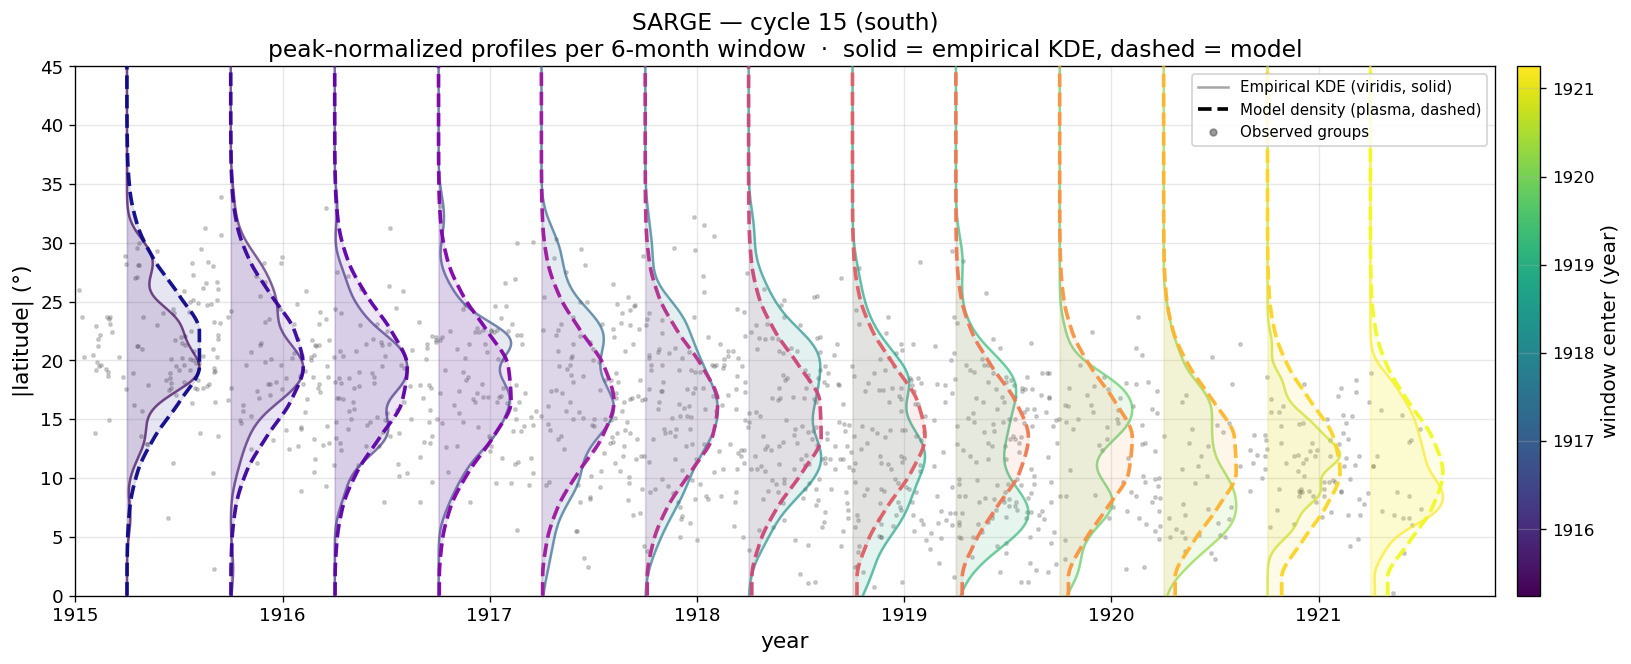

In [24]:
fig_sarge, _ = task20_figure(hc_sel, "SARGE")
plt.show()

### Classical

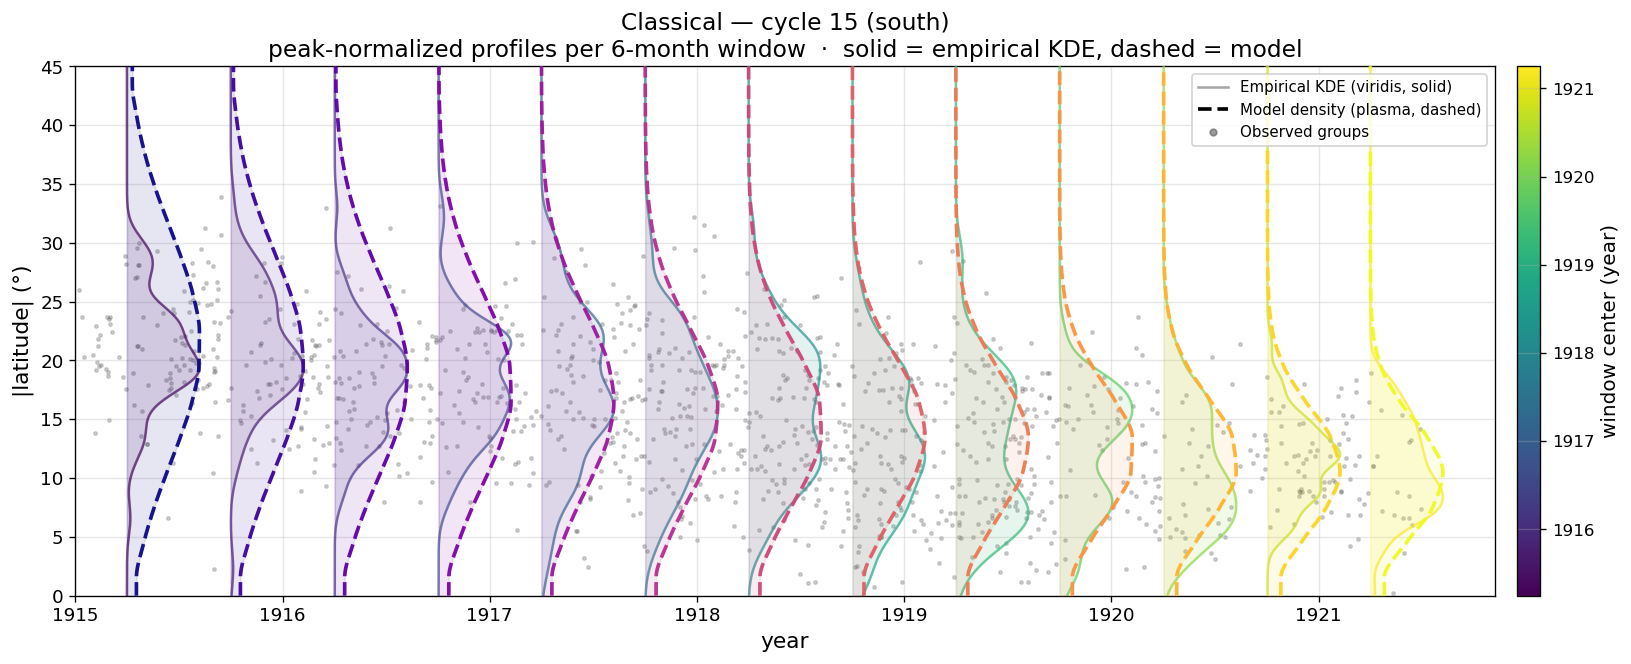

In [25]:
fig_classical, _ = task20_figure(hc_sel, "Classical")
plt.show()

### Classical + AI `base_cat`  (mean of 1000 realizations)

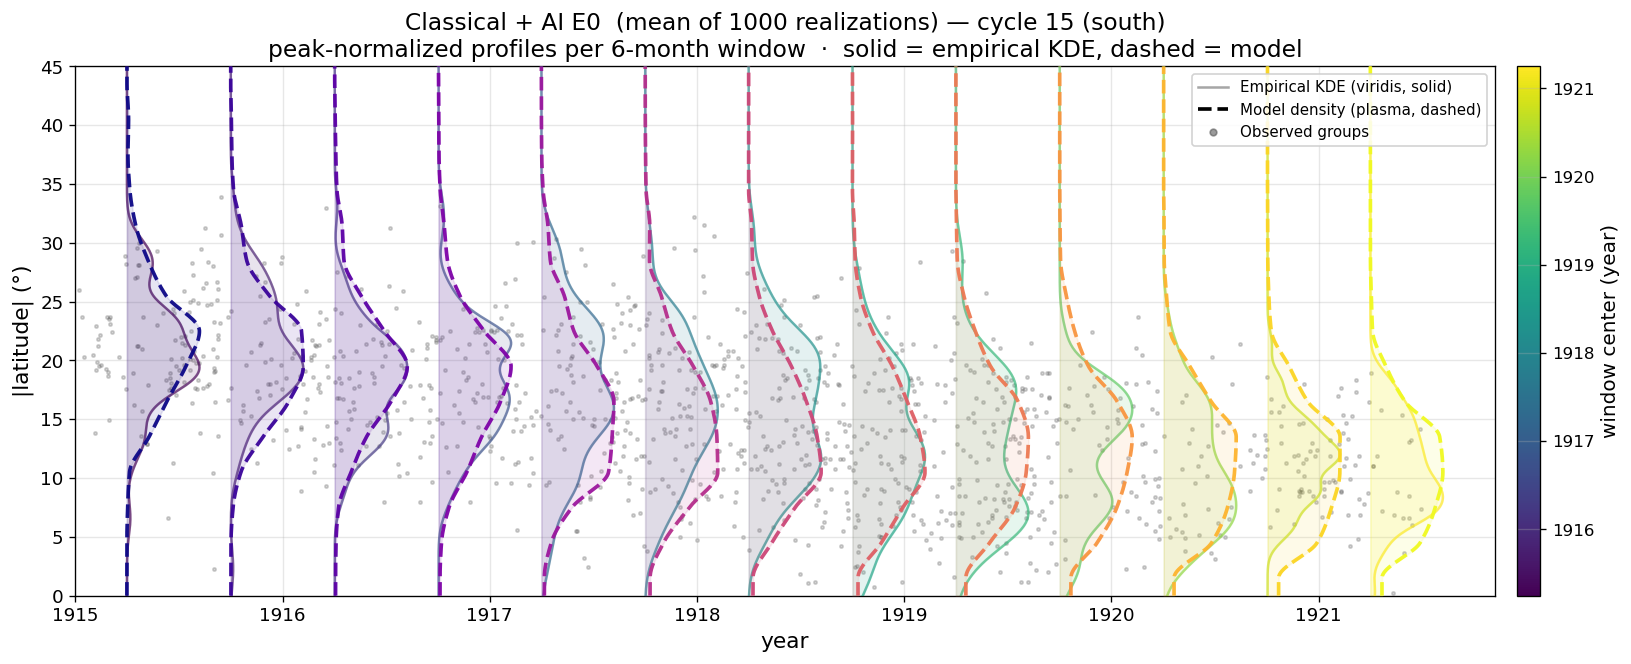

In [26]:
fig_ai, _ = task20_figure(hc_sel, AI_ROW)
plt.show()

In [ ]:
# Requirement check: the three figures must be geometrically interchangeable.
_geo = [(tuple(np.round(f.get_size_inches(), 6)),
         tuple(np.round(f.axes[0].get_position().bounds, 9)),
         tuple(np.round(f.axes[0].get_xlim(), 9)),
         tuple(np.round(f.axes[0].get_ylim(), 9)))
        for f in (fig_sarge, fig_classical, fig_ai)]
for row, g in zip(TASK20_ROWS, _geo):
    print(f"{row:<20} size={g[0]}  axes={g[1]}  xlim={g[2]}  ylim={g[3]}")
assert len(set(_geo)) == 1, "figure geometry differs between models — slides would jump"
print("\nOK — identical figure size, axes rectangle and limits across the three models.")

### All three models × all six test hemicycles

The same panels tiled like the rasters above: rows are models, columns are the held-out
hemispheric cycles, column widths proportional to cycle duration so one year scale is
shared. Every panel carries the same solid-viridis empirical KDE; only the dashed-plasma
model curve changes down a column. Profiles are coloured by **τ**, years since the
classical t₀, so a single colourbar is valid across columns that live in different
centuries.

In [ ]:
_t_by = {tag_of(hc): maps_by_hc[tag_of(hc)]["Classical"][1] for hc in test_hcs}
_t0_by = {tag_of(hc): float(classical.lookup_t0(int(hc["cycle"]), hc["hemisphere"]))
          for hc in test_hcs}
_taus = np.concatenate([_t_by[tag_of(hc)] - _t0_by[tag_of(hc)]
                        for hc in test_hcs if _t_by[tag_of(hc)].size])
_norm = plt.Normalize(vmin=float(_taus.min()), vmax=float(_taus.max()))

col_spans = [max(float(np.ptp(_t_by[tag_of(hc)])), 0.5) if _t_by[tag_of(hc)].size else 1.0
             for hc in test_hcs]
nrows, ncols = len(TASK20_ROWS), len(test_hcs)
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(0.55 * sum(col_spans) + 2.0, 2.7 * nrows),
                         sharey=True, squeeze=False,
                         gridspec_kw={"width_ratios": col_spans},
                         layout="constrained")

for j, hc in enumerate(test_hcs):
    tg = tag_of(hc)
    for i, row in enumerate(TASK20_ROWS):
        ax = axes[i, j]
        draw_task20_panel(ax, hc, row, _norm, color_by="tau")
        # Headroom above 45 deg: the metric box is anchored upper-left and would sit on
        # top of the first profiles otherwise (in the raster grids it had a dark, empty
        # corner to live in).
        ax.set_ylim(LAT_BINS[0], LAT_BINS[-1] + 7.0)
        ax.set_yticks(np.arange(0, LAT_BINS[-1] + 1, 10))
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        ax.grid(alpha=0.3)
        if i == 0:
            ax.set_title(tg, fontsize=15, fontweight="bold")
        if j == 0:
            ax.set_ylabel(f"{ROW_SHORT[row]}\n|lat| (°)", fontsize=12)
        if i == nrows - 1:
            ax.set_xlabel("year", fontsize=13)
        ax.tick_params(labelsize=11)
        if row in metrics_by_hc[tg]:
            draw_metric_box(ax, metrics_by_hc[tg][row], metric_colors(tg)[row],
                            metric_keys=_shown_metrics)

_sm = plt.cm.ScalarMappable(cmap=CMAP_EMP, norm=_norm)
_sm.set_array([])
cbar = fig.colorbar(_sm, ax=axes.ravel().tolist(), aspect=40, pad=0.01)
cbar.set_label("τ  (years since cycle t₀)", fontsize=13)
cbar.ax.tick_params(labelsize=11)
fig.suptitle("Test-set butterfly diagrams, Task-20 style — peak-normalized profiles per "
             "6-month window over the observed groups\n"
             "solid viridis = empirical KDE   ·   dashed plasma = model   "
             f"(rows = model, columns = held-out hemicycle; "
             f"{AI_SHORT} = mean of {K} realizations)", fontsize=16)
try:
    fig.get_layout_engine().set(w_pad=0.02, h_pad=0.02, wspace=0.03, hspace=0.04)
except Exception:
    pass
plt.show()